In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Import data

In [2]:
import pandas as pd

gym = pd.read_csv("dataset/gym_members_exercise_tracking.csv")
gym.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [3]:
gym.dtypes

Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                      object
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object

In [4]:
gym.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


# Preprocessing the data

In [5]:
print(gym.columns.to_list())

['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']


In [6]:
gym = gym.rename(columns={
    "Weight (kg)": "Weight",
    "Height (m)": "Height",
    "Session_Duration (hours)": "Session_Duration",
    "Water_Intake (liters)": "Water_Intake",
    "Workout_Frequency (days/week)": "Workout_Frequency"
})

print(gym.columns.to_list())

['Age', 'Gender', 'Weight', 'Height', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake', 'Workout_Frequency', 'Experience_Level', 'BMI']


In [7]:
gym["Gender"] = pd.Categorical(gym["Gender"],ordered=False)
gym["Workout_Type"] = pd.Categorical(gym["Workout_Type"],ordered=False)
gym["Workout_Frequency"] = pd.Categorical(gym["Workout_Frequency"],ordered=False)
gym["Experience_Level"] = pd.Categorical(gym["Experience_Level"],ordered=False)


In [8]:
gym.head()

,Age,Gender,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake,Workout_Frequency,Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [9]:
gym.dtypes

Age                     int64
Gender               category
Weight                float64
Height                float64
Max_BPM                 int64
Avg_BPM                 int64
Resting_BPM             int64
Session_Duration      float64
Calories_Burned       float64
Workout_Type         category
Fat_Percentage        float64
Water_Intake          float64
Workout_Frequency    category
Experience_Level     category
BMI                   float64
dtype: object

In [10]:
quali = gym.select_dtypes(include=["category","object"]).columns.to_list()
quanti = gym.select_dtypes(exclude=["category","object"]).columns.to_list()
print(f"Categorical variables: {quali}")
print(f"Quantitative variables: {quanti}")

Categorical variables: ['Gender', 'Workout_Type', 'Workout_Frequency', 'Experience_Level']
Quantitative variables: ['Age', 'Weight', 'Height', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake', 'BMI']


In [11]:
# Check if there is error on type.

In [12]:
# Check missing data
print(f"The number of value missing is:")
gym.isnull().sum()

The number of value missing is:


Age                  0
Gender               0
Weight               0
Height               0
Max_BPM              0
Avg_BPM              0
Resting_BPM          0
Session_Duration     0
Calories_Burned      0
Workout_Type         0
Fat_Percentage       0
Water_Intake         0
Workout_Frequency    0
Experience_Level     0
BMI                  0
dtype: int64

In [13]:
# Checking duplicate row
print(f"The number of duplicate rows is : {gym.duplicated().sum()}")

The number of duplicate rows is : 0


**Comment:** Our data set is clean - none of it is missing and there are no duplicates.

# Uni-dimensional Analyse

## Categorical variables

In [14]:
gym.columns

Index(['Age', 'Gender', 'Weight', 'Height', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration', 'Calories_Burned', 'Workout_Type',
       'Fat_Percentage', 'Water_Intake', 'Workout_Frequency',
       'Experience_Level', 'BMI'],
      dtype='object')

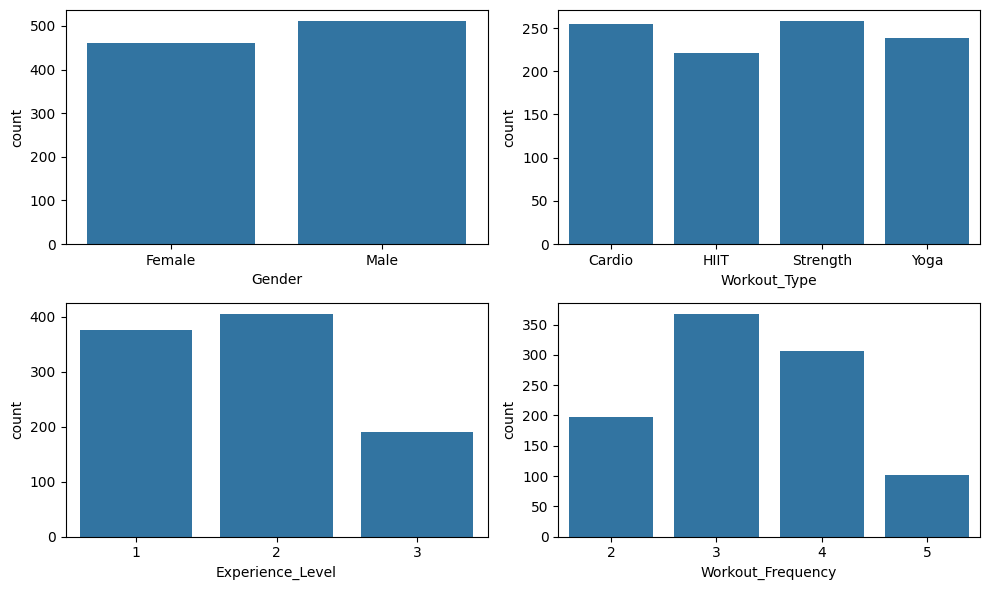

In [15]:
import seaborn as sns
fig = plt.subplots(2,2,figsize=(10,6))
plt.subplot(2,2,1)
sns.barplot(gym["Gender"].value_counts())

plt.subplot(2,2,2)
sns.barplot(gym["Workout_Type"].value_counts())

plt.subplot(2,2,3)
sns.barplot(gym["Experience_Level"].value_counts())

plt.subplot(2,2,4)
sns.barplot(gym["Workout_Frequency"].value_counts())

plt.tight_layout()
plt.show()

## Quantitative variable

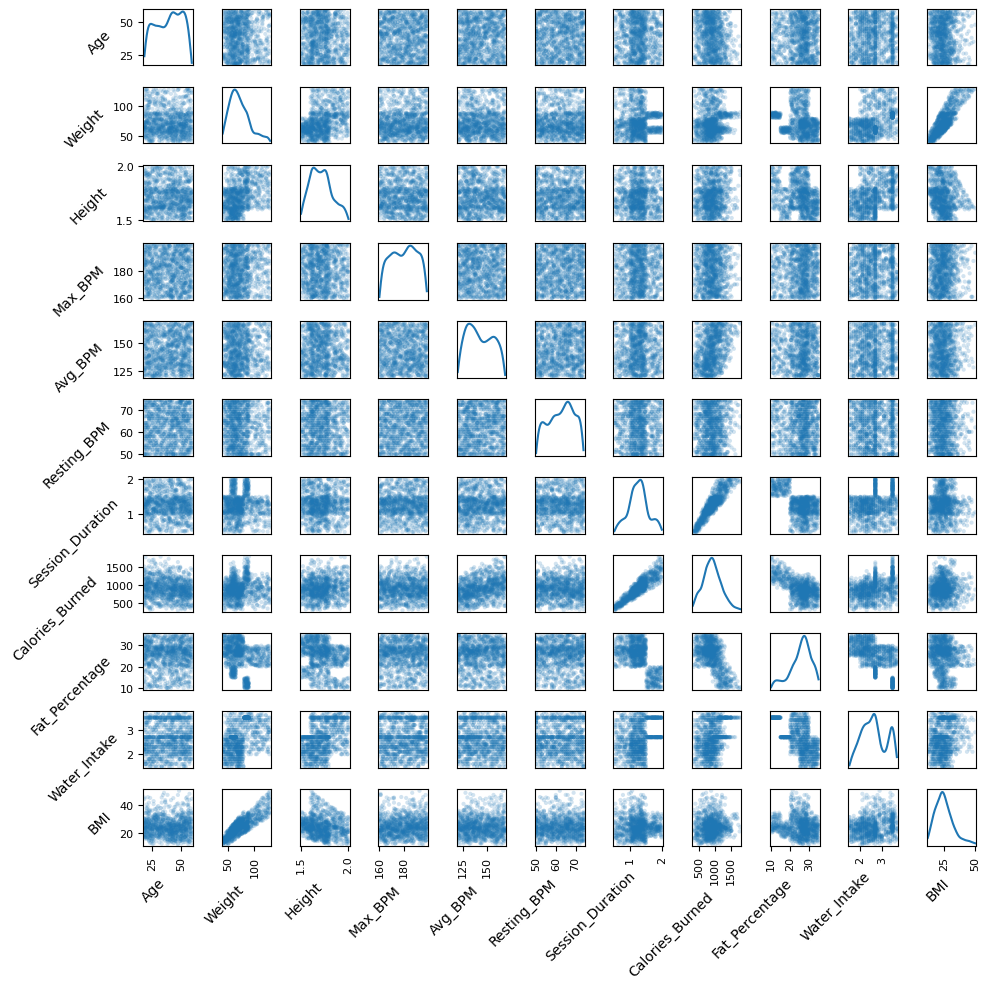

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

from pandas.plotting import scatter_matrix

# Create the scatter matrix
sm = scatter_matrix(gym[['Age', 'Weight', 'Height', 'Max_BPM', 'Avg_BPM','Resting_BPM',
               'Session_Duration', 'Calories_Burned','Fat_Percentage', 'Water_Intake', 'BMI']],
              alpha=0.2,
              diagonal='kde',
              figsize=(10,10))

# Get the current figure
fig = plt.gcf()

# Loop through all axes in the figure
for ax in fig.axes:
    # Rotate the variable names on the diagonal plots
    if ax.get_title():
        ax.set_title(ax.get_title(), rotation=45, ha='right')

    # Rotate the variable names on the off-diagonal plots
    if ax.get_xlabel():
        ax.set_xlabel(ax.get_xlabel(), rotation=45, ha='right')
    if ax.get_ylabel():
        ax.set_ylabel(ax.get_ylabel(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

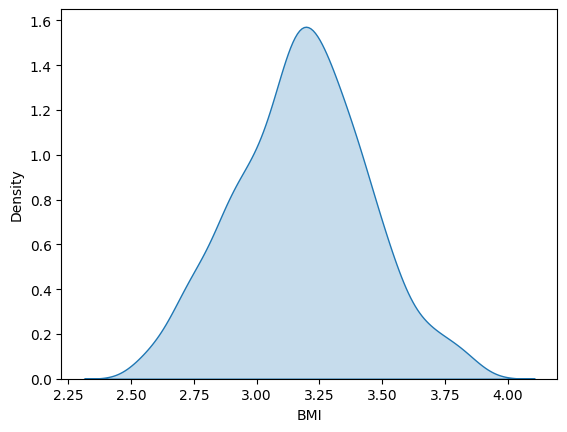

quanti, before: ['Age', 'Weight', 'Height', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake', 'BMI']
quanti, after : ['Age', 'Weight', 'Height', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake', 'LBMI']


In [17]:
var = 'BMI'
sns.kdeplot(np.log(gym[var]),label='var',fill=True)
plt.show()
gym['LBMI'] = np.log(gym['BMI'])
del gym['BMI']
print(f"quanti, before: {quanti}")
i = quanti.index(var)
quanti.insert(i,"LBMI")
quanti.remove(var)
print(f"quanti, after : {quanti}")

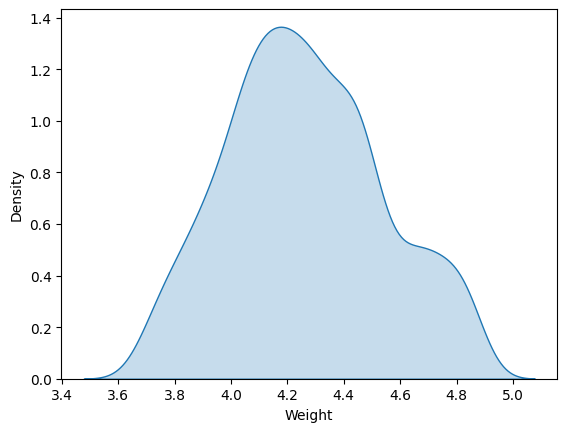

quanti, before: ['Age', 'Weight', 'Height', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake', 'LBMI']
quanti, after : ['Age', 'LWeight', 'Height', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake', 'LBMI']


In [18]:
var = 'Weight'
sns.kdeplot(np.log(gym[var]),label='var',fill=True)
plt.show()
gym['LWeight'] = np.log(gym['Weight'])
del gym['Weight']
print(f"quanti, before: {quanti}")
i = quanti.index(var)
quanti.insert(i,"LWeight")
quanti.remove(var)
print(f"quanti, after : {quanti}")

In [19]:
print(gym.columns.to_list())

['Age', 'Gender', 'Height', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake', 'Workout_Frequency', 'Experience_Level', 'LBMI', 'LWeight']


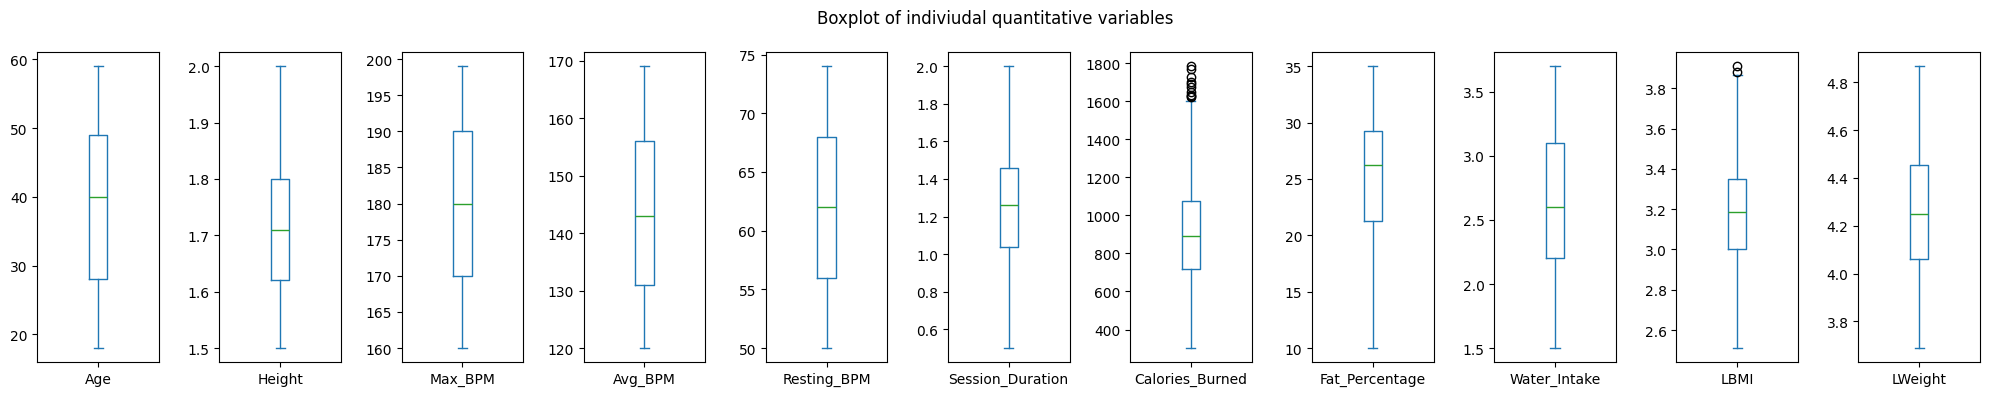

---------------


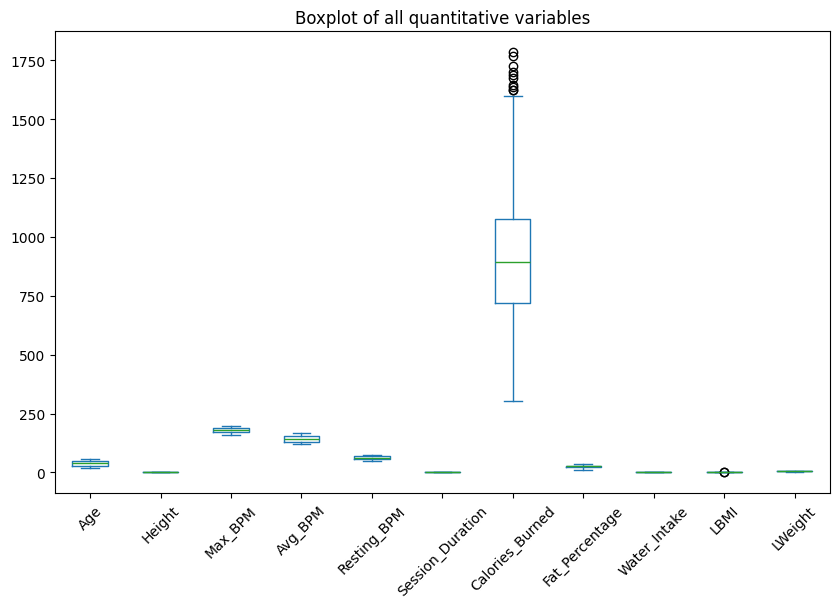

In [20]:
quanti = ['Age', 'Height', 'Max_BPM', 'Avg_BPM', 'Resting_BPM',
       'Session_Duration', 'Calories_Burned', 'Fat_Percentage',
       'Water_Intake', 'LBMI', 'LWeight']
n = len(quanti)

fig, Ax = plt.subplots(1,n, figsize=(20,4))
for i, qntcol in enumerate(quanti):
    gym[qntcol].plot(kind="box", ax=Ax[i])
fig.suptitle("Boxplot of indiviudal quantitative variables")
plt.tight_layout()
plt.show()

print("---------------")
# plt.title("Boxplot of all quantitative variables")
gym[quanti].plot(kind="box", figsize=(10,6), title="Boxplot of all quantitative variables")
plt.xticks(rotation=45)
plt.show()

## Multi-dimensionnal Analyse

### Quanti vs Quanti

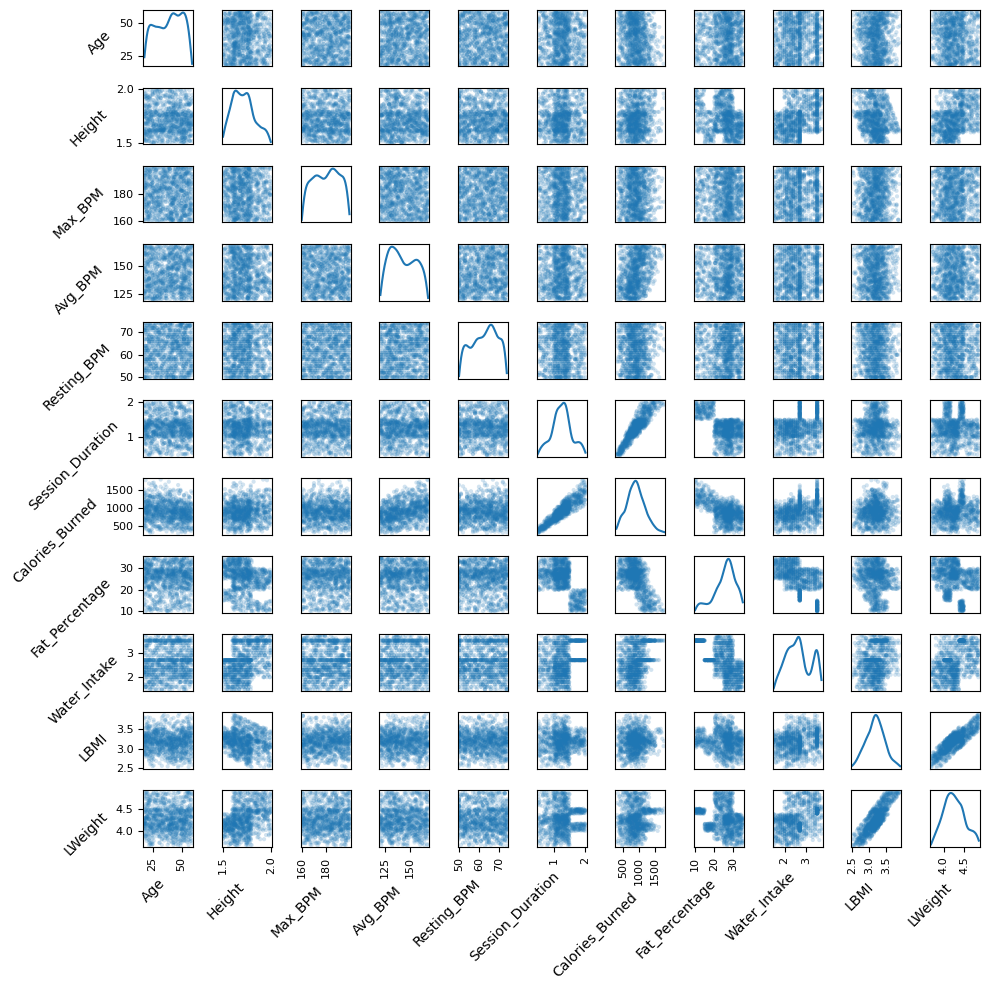

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'gym' is your DataFrame
from pandas.plotting import scatter_matrix

# Create the scatter matrix
sm = scatter_matrix(gym[quanti],
              alpha=0.2,
              diagonal='kde',
              figsize=(10,10))

# Get the current figure
fig = plt.gcf()

# Loop through all axes in the figure
for ax in fig.axes:
    # Rotate the variable names on the diagonal plots
    if ax.get_title():
        ax.set_title(ax.get_title(), rotation=45, ha='right')

    # Rotate the variable names on the off-diagonal plots
    if ax.get_xlabel():
        ax.set_xlabel(ax.get_xlabel(), rotation=45, ha='right')
    if ax.get_ylabel():
        ax.set_ylabel(ax.get_ylabel(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

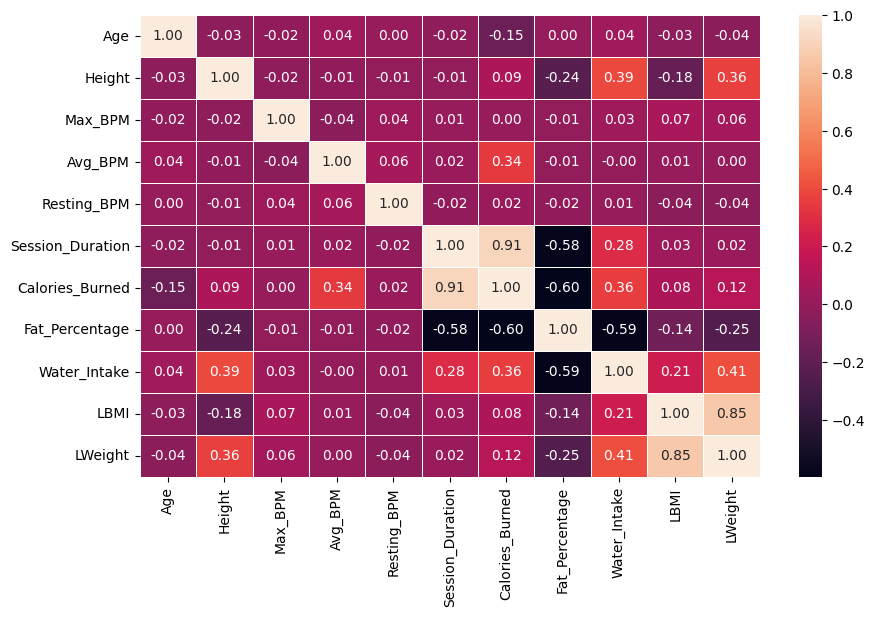

In [22]:
corr = gym[quanti].corr()

plt.figure(figsize = (10,6))
sns.heatmap(corr, annot = True, fmt='.2f',linewidths=0.5)
plt.show()

**Remark**: 
We observe a **strong** correlation between the following pairs of variables: 
- Session_Duration & Calories_Burned (0.91)
- LBMI & LWeight (0.85)

We observe **moderate** correlation between the following pairs of variables:
- Calories_Burned & Fat_Percentage (-0.60)
- Session_Duration & Fat_Percentage (-0.58)
- Fat_Percentage & Water_Intake (-0.59)

We observe **above average** correlation between the following pairs of variables:
- Water_Intake & LWeight (0.41)
- Water_Intake & Height (0.39)
- Height & Water_Intake (0.39)
- Height & LWeight (0.36)
- Calories_Burned & Water_Intake (0.36)
- Water_Intake & Calories_Burned (0.36)
- AVG_BPM & Calories_Burned (0.34)

We observe a **slight** correlation between the following pairs of variables:
- Water_Intake & Session_Duration (0.28)
- Fat_Percentage & LWeight (-0.25)
- Height & Fat_Percentage (-0.24)
- Fat_Percentage & Height (-0.24)
- Water_Intake & LBMI (0.21)
- Height & LBMI (-0.18)
- Calories_Burned & Age (-0.15)
- Age & Calories_Burned (-0.15)
- Fat_Percentage & LBMI (-0.14)
- Calories_Burned & LWeight (0.12)

The rest of the pairs of variables have a correlation close to zero, meaning that they are practically independent.

### Quali vs Quali

In [23]:
gym.columns

Index(['Age', 'Gender', 'Height', 'Max_BPM', 'Avg_BPM', 'Resting_BPM',
       'Session_Duration', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage',
       'Water_Intake', 'Workout_Frequency', 'Experience_Level', 'LBMI',
       'LWeight'],
      dtype='object')

Workout_Type  Cardio  HIIT  Strength  Yoga
Gender                                    
Female           126   107       123   106
Male             129   114       135   133


<Figure size 1000x600 with 0 Axes>

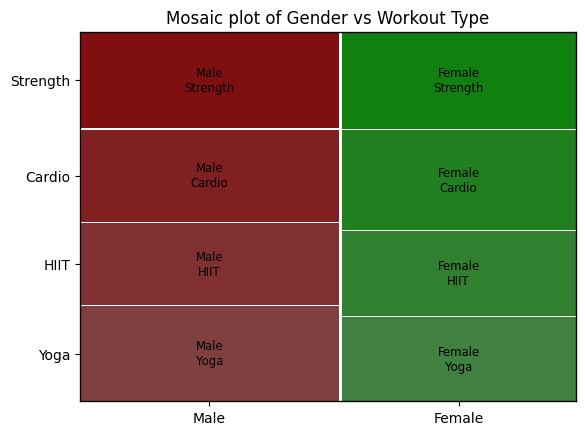

In [24]:
from statsmodels.graphics.mosaicplot import mosaic
gender_workoutType = pd.crosstab(gym['Gender'],gym['Workout_Type'])
print(gender_workoutType)

fig = plt.figure(figsize=(10,6))
mosaic(gym,['Gender','Workout_Type'],title='Mosaic plot of Gender vs Workout Type')
plt.show()


**Remark**: The type of workout does not seem to depend on gender.

Workout_Frequency    2    3    4   5
Gender                              
Female              87  178  150  47
Male               110  190  156  55


<Figure size 1000x600 with 0 Axes>

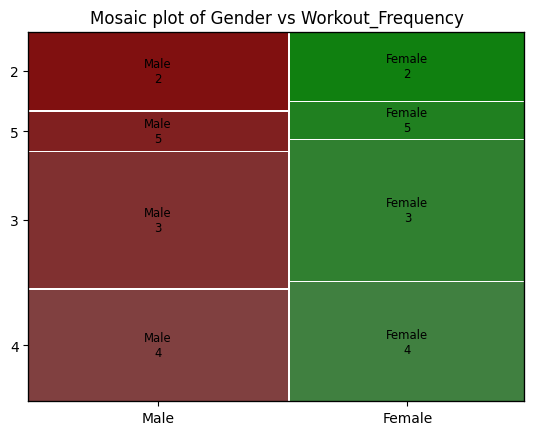

In [25]:
gender_workoutType = pd.crosstab(gym['Gender'],gym['Workout_Frequency'])
print(gender_workoutType)

fig = plt.figure(figsize=(10,6))
mosaic(gym,['Gender','Workout_Frequency'],title='Mosaic plot of Gender vs Workout_Frequency')
plt.show()


**Remark**: The workout frequency does not seem to depend on gender.

Experience_Level    1    2    3
Gender                         
Female            179  193   90
Male              197  213  101


<Figure size 1000x600 with 0 Axes>

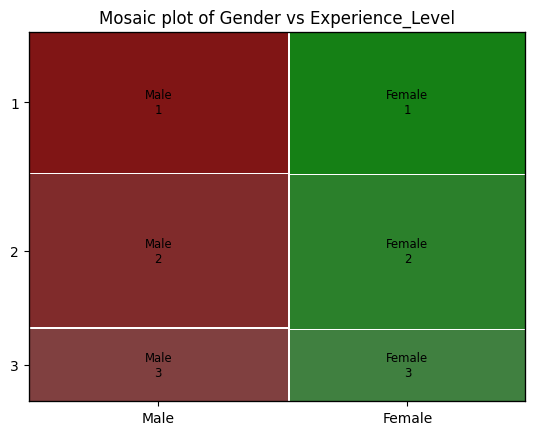

In [26]:
gender_workoutType = pd.crosstab(gym['Gender'],gym['Experience_Level'])
print(gender_workoutType)

fig = plt.figure(figsize=(10,6))
mosaic(gym,['Gender','Experience_Level'],title='Mosaic plot of Gender vs Experience_Level')
plt.show()

**Remark**: The experience level does not seem to depend on gender.

Workout_Frequency   2    3   4   5
Workout_Type                      
Cardio             63   92  77  23
HIIT               42   86  67  26
Strength           45  102  85  26
Yoga               47   88  77  27


<Figure size 1000x600 with 0 Axes>

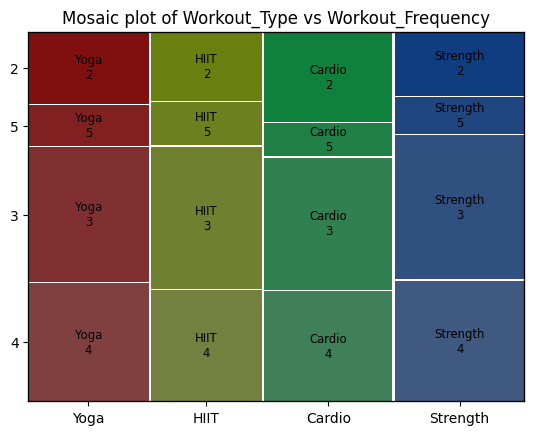

In [27]:
gender_workoutType = pd.crosstab(gym['Workout_Type'],gym['Workout_Frequency'])
print(gender_workoutType)

fig = plt.figure(figsize=(10,6))
mosaic(gym,['Workout_Type','Workout_Frequency'],title='Mosaic plot of Workout_Type vs Workout_Frequency')
plt.show()

**Remark**: The workout type does not seem to depend on workout frequency.

Experience_Level    1    2   3
Workout_Type                  
Cardio            109  102  44
HIIT               85   87  49
Strength           97  116  45
Yoga               85  101  53


<Figure size 1000x600 with 0 Axes>

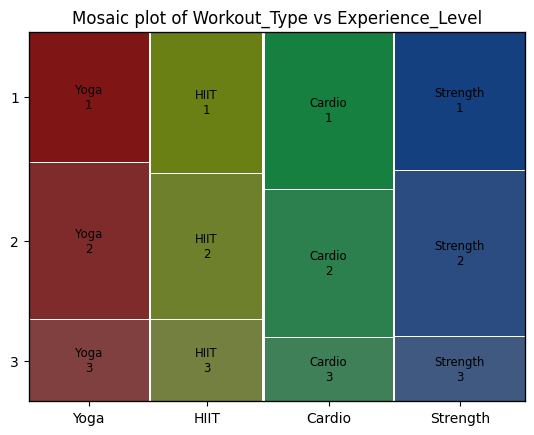

In [28]:
gender_workoutType = pd.crosstab(gym['Workout_Type'],gym['Experience_Level'])
print(gender_workoutType)

fig = plt.figure(figsize=(10,6))
mosaic(gym,['Workout_Type','Experience_Level'],title='Mosaic plot of Workout_Type vs Experience_Level')
plt.show()

**Remark**: The workout type does not seem to depend on workout frequency.

Experience_Level     1    2    3
Workout_Frequency               
2                  197    0    0
3                  179  189    0
4                    0  217   89
5                    0    0  102


<Figure size 1000x600 with 0 Axes>

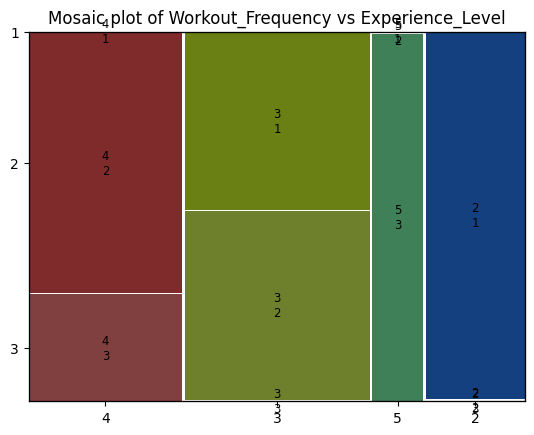

In [29]:
gender_workoutType = pd.crosstab(gym['Workout_Frequency'],gym['Experience_Level'])
print(gender_workoutType)

fig = plt.figure(figsize=(10,6))
mosaic(gym,['Workout_Frequency','Experience_Level'],title='Mosaic plot of Workout_Frequency vs Experience_Level')
plt.show()

**Remark**: The contingency table is bi-diagonal, we can say that a person with more experience goes to the gym more often.

### Quanti vs Quali

In [30]:
print(gym.columns.to_list())
quali = ['Gender','Workout_Type','Workout_Frequency','Experience_Level']
print("--------")
print(f"qualitative variables: {quali}")

['Age', 'Gender', 'Height', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake', 'Workout_Frequency', 'Experience_Level', 'LBMI', 'LWeight']
--------
qualitative variables: ['Gender', 'Workout_Type', 'Workout_Frequency', 'Experience_Level']


In [31]:
def MakeBox(qcol, data=gym):
    fig, Axes = plt.subplots(3,4,figsize=(12,7))
    fig.suptitle(f"Boxplot of all quantitative variables according to {qcol}")
    Axes = np.ravel(Axes)
    for i, qntcol in enumerate(quanti):
        sns.boxplot(x=qcol, y=qntcol, data=data, showfliers=True, hue=qcol, ax=Axes[i])
        Axes[i].set_xticklabels(Axes[i].get_xticklabels(), rotation=45)
        if Axes[i].get_legend() is not None:
            Axes[i].get_legend().remove() # we do not want a legend
    plt.tight_layout()
    return fig, Axes

In [32]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

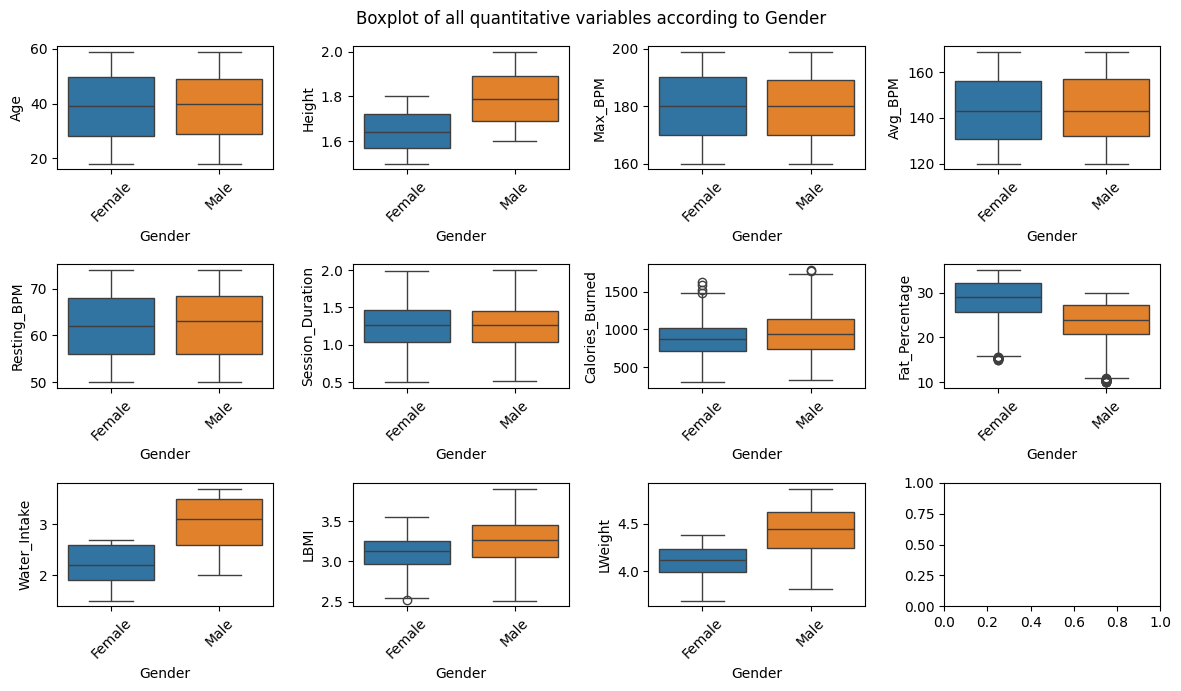

In [33]:
fig, Axes = MakeBox(quali[0])

**Comments:** 
- We observe that the quantitative variable *Height* depends on the qualitative variable *Gender*, with males showing higher *Height* values than females, on average.
- We observe that the quantitative variable *Fat_Percentage* depends on the qualitative variable *Gender*, with females showing higher *Fat_Percentage* values than males, on average.
- We observe similar relationships between *Gender* and respectively the quantitative variables *Water_Intake* and *LWeight*, as for *Gender* and *Height*
- We also note that the quantitative variables *Calories_burned* and *LBMI* depends on *Gender* to a certain extent, with males having a span of values that go higher than the span for females

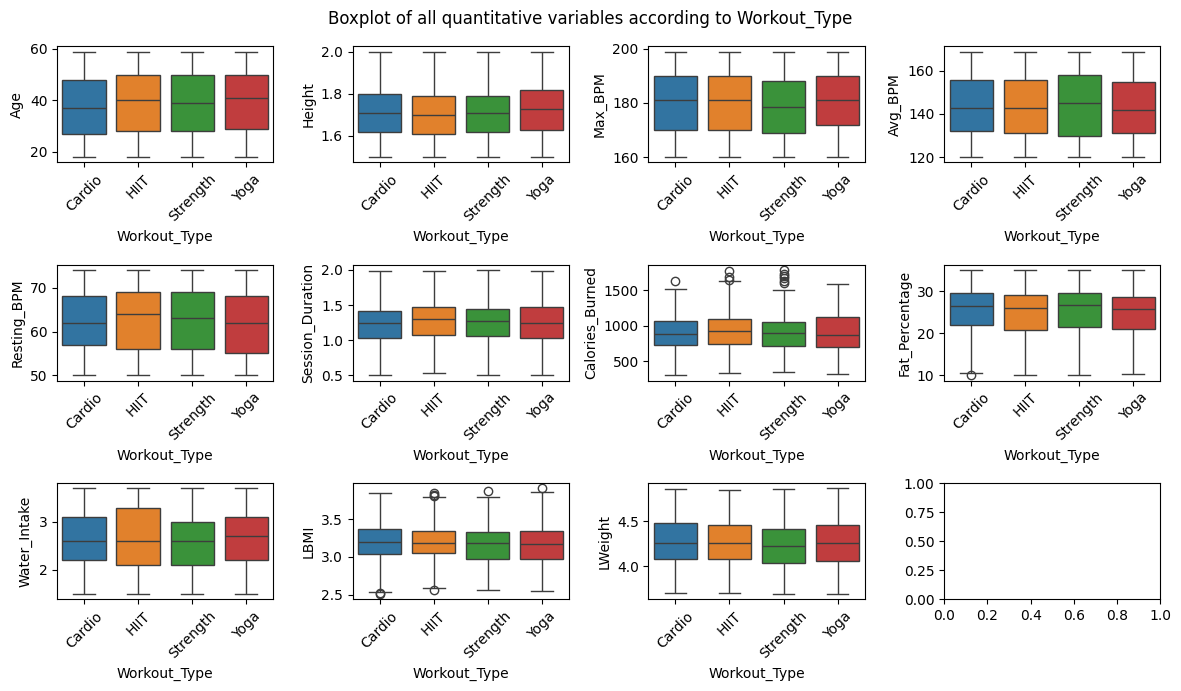

In [34]:
fig, Axes = MakeBox(quali[1])

**Comment:** 
- There are no significant relationships between the quantitative variables and the qualitative *Workout_Type* variable.
- Apart from this, we observe a large amount of high value outliers for the *Calories_Burned* variable for the HIIT and Strength modalitites of *Workout_Type*

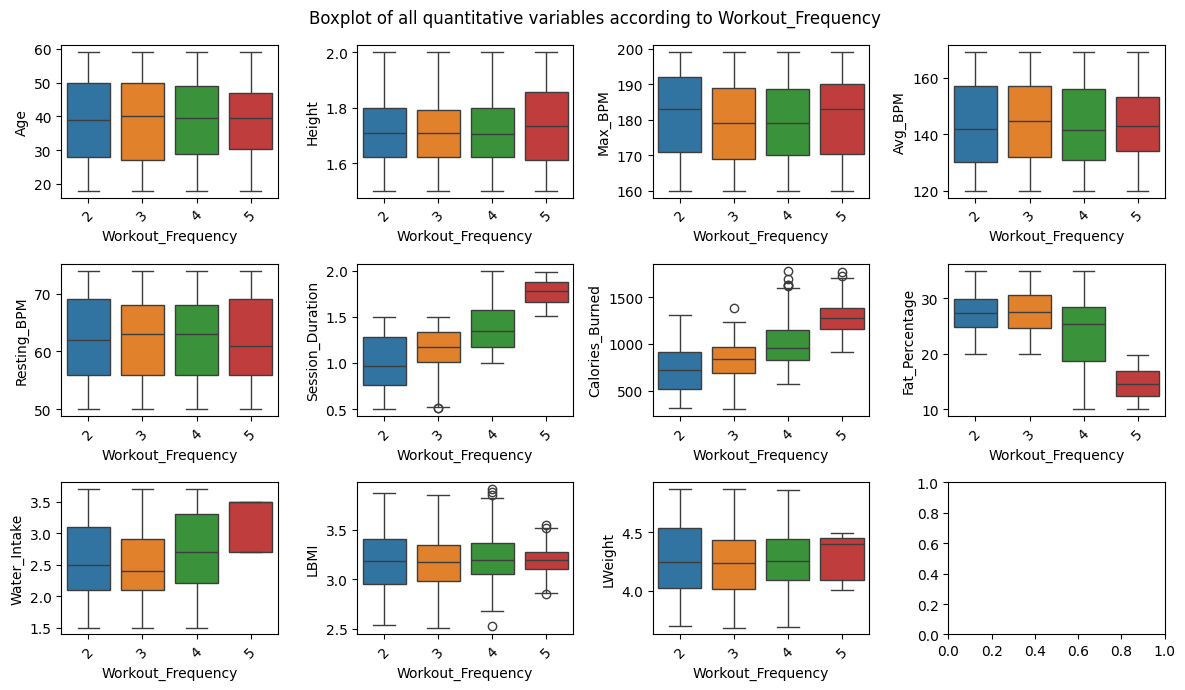

In [35]:
fig, Axes = MakeBox(quali[2])

**Comments:**
- We observe that the qualitiative variable *Workout_Frequency* presents strong relationships with many of the quantitative variables.
- Gym goers training 5 times a week are on average taller than gym goers who train 2, 3, or 4 times per week. They also tend to have a smaller age, average BPM, and weight span than the other gym goers.
- The max BPM of gym goers who train 2 or 5 times per week is on average higher than the max BPM of gym goers training 3 or 4 times per week. Similarily, the resting BPM of gym goers training 2 or 5 times per week is also slightly lower than the resting BPM of gym goers training 3 or 4 times per week.
- The average session duration and the span of values tends to increase and decrease respectively, when the workout frequency increases. An identical behaviour is observed for the quantitative variable *Calories_Burned*.
- *Fat_Percentage* takes lower values on average among individuals with a *Workout_Frequency* of 4 or 5, as compared to individuals with a *Workout_Frequency* of 2 or 3.
- The *Water_Intake* variable has no whisker when *Workout_Frequency* takes a value of 5. This is commented later on in the notebook.
- The *LBMI* variable has a span that decreases in width as the *Workout_Frequency* increases.

In [36]:
gym["Workout_Frequency"].value_counts()

Workout_Frequency
3    368
4    306
2    197
5    102
Name: count, dtype: int64

**Further comment:** Some of the decrease in variance/span that we observe as *Workout_Frequency* increases can be explained from there being less individuals in our survey training more than 4 times per week.

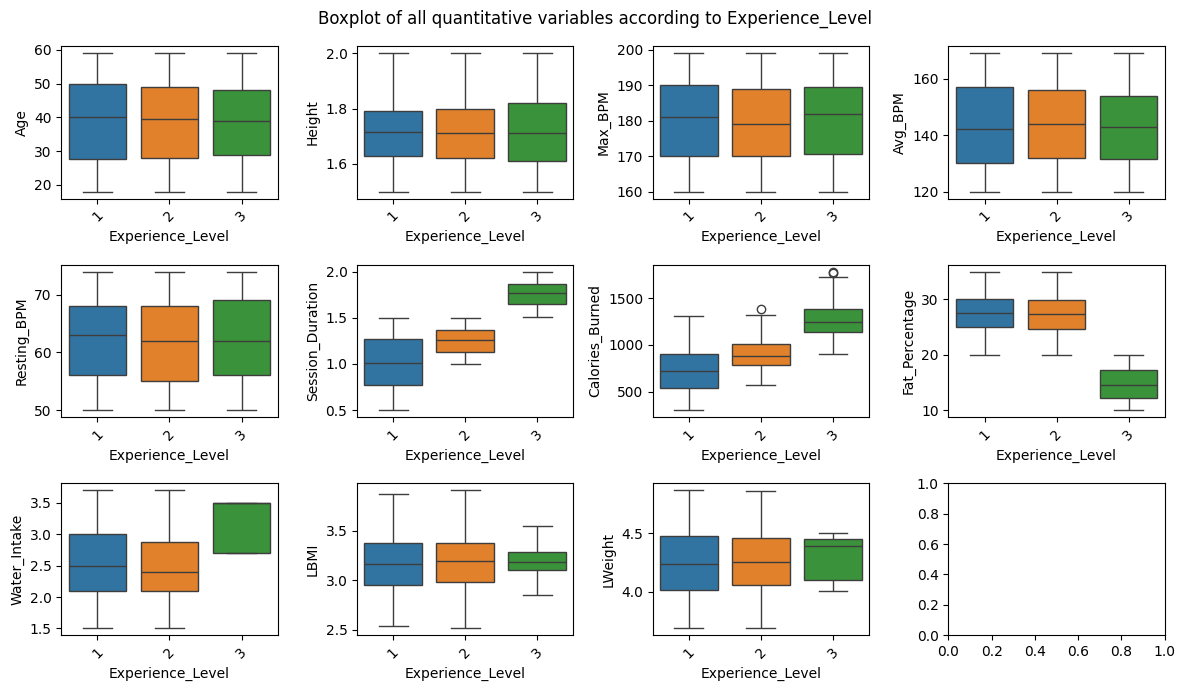

In [37]:
fig, Axes = MakeBox(quali[3])

**Comment:** We observe a similar relationship between the *Experience_Level* and the quantitative variables as observed between the *Workout_Frequency* and the quantitative variables. The abnormal behaviour of *Water_Intake* will be explored subsequently.

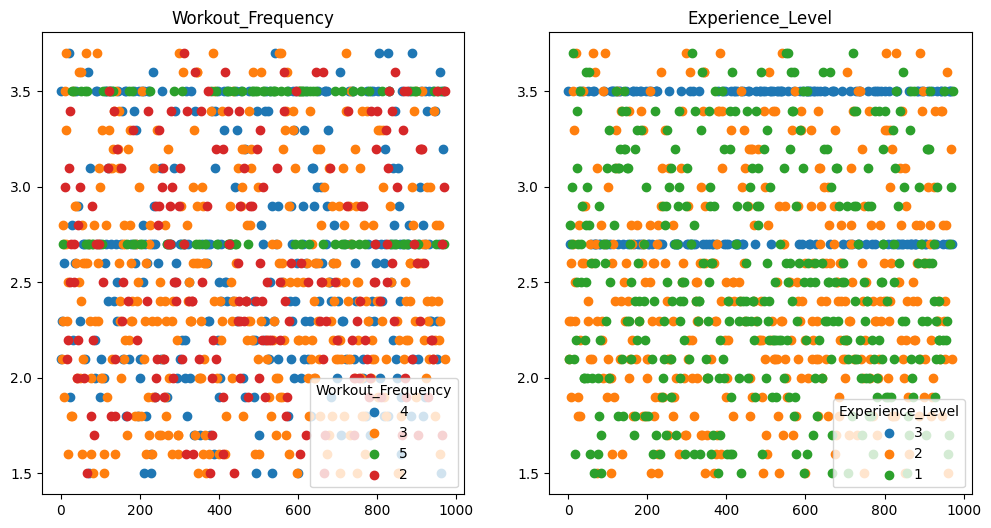

In [38]:
temp = gym['Water_Intake']
l = np.arange(len(temp))
cmap = plt.get_cmap("tab10")

fig, Axes = plt.subplots(1,2,figsize=(12,6))
Axes = np.ravel(Axes)
for i, qcol in enumerate(["Workout_Frequency", "Experience_Level"]):
    for j,mod in enumerate(gym[qcol].unique()):
        bmap = gym[qcol]==mod
        Axes[i].scatter(l[bmap], temp[bmap], label=str(mod), color=cmap.colors[j])
    Axes[i].set_title(qcol)
    Axes[i].legend(title=qcol)
plt.show()

**Remark 1**: *Water_Intake* seems to behave as a categorical/qualitative variable, especially when *Workout_Frequency* is 5 or *Experience_Level* is 3. 

This could be due to water intake being reported in liters, and without more precision than one decimal point. Although the 'discreteness' of *Water_Intake* is more extreme for individuals traing 5 times a week or with an experience level of 3, essentially becoming a binary variable, this specific behaviour shouldn't impact the type of the variable as a whole.  The same argument could be made for *Age* being a hidden qualitative variable, but traditionnally we have kept it as quantitative. We will do the same for *Water_Intake*. 

In [39]:
gym['Water_Intake'] = gym['Water_Intake'].astype('category')

In [40]:
gym['Water_Intake'].unique()

[3.5, 2.1, 2.3, 2.8, 2.7, ..., 3.6, 2.4, 1.5, 1.7, 3.2]
Length: 23
Categories (23, float64): [1.5, 1.6, 1.7, 1.8, ..., 3.4, 3.5, 3.6, 3.7]

**Remark 2:** There being 23 distinct values for *Water_Intak* also makes it seem unreasonable to change it's type. We are also not considering creating bins, because then we could change the type of any quantitative variable.

In [41]:
gym['Water_Intake'] = gym['Water_Intake'].astype('float64')

# Principal component Analyse (PCA)

In [42]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

X = scale(gym[quanti])

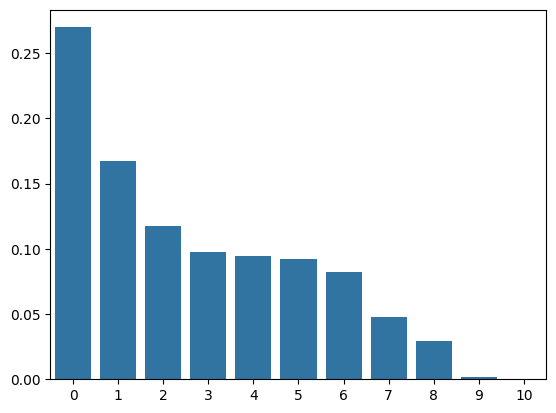

In [43]:
pca = PCA()
X_pca = pca.fit(X).transform(X)
sns.barplot(pca.explained_variance_ratio_)
plt.show()

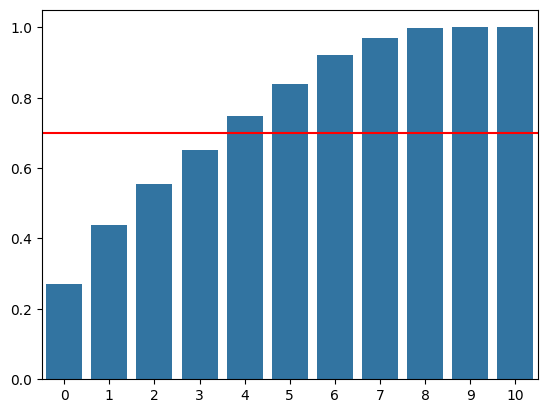

In [44]:
sns.barplot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.7,color='r',linestyle='-')
plt.show()

In [45]:
gym['Gender'].mode()

0    Male
Name: Gender, dtype: category
Categories (2, object): ['Female', 'Male']

**Remark**: The first four axes occupy more than 70% of the total variation, we can therefore keep only these 4 axes.

### Representation of individuals

In [46]:
male_idx = gym['Gender'] =='Male'
experi = pca.explained_variance_ratio_

In [ ]:
def pca_ind_plot()

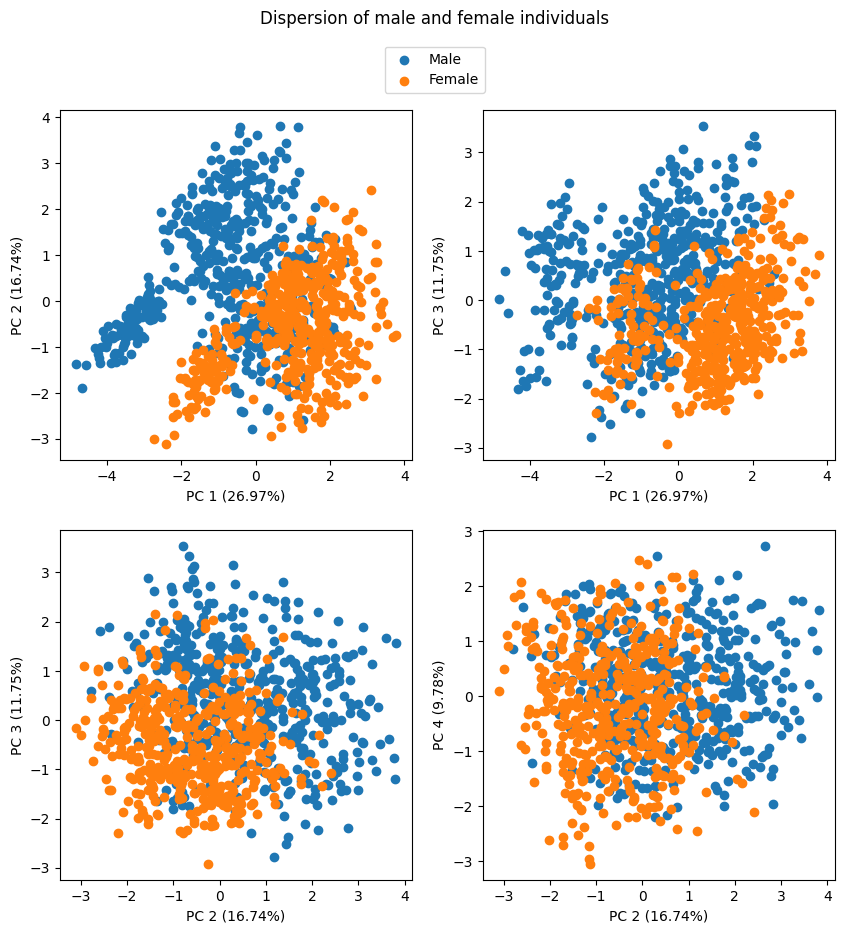

In [47]:
from itertools import product
fig,Ax = plt.subplots(2,2,figsize=(10,10))
x_axis = [0,0,1,1]
y_axis = [1,2,2,3]
for i,j in product(range(2),range(2)):
    Ax[i,j].scatter(X_pca[male_idx,x_axis[2*i+j]],X_pca[male_idx,y_axis[2*i+j]],label='Male' if 2*i+j==0 else "")
    Ax[i,j].scatter(X_pca[~male_idx,x_axis[2*i+j]],X_pca[~male_idx,y_axis[2*i+j]],label='Female' if 2*i+j==0 else "")
    Ax[i,j].set_xlabel(f"PC {int(x_axis[2*i+j]+1)} ({100*experi[x_axis[2*i+j]]:.2f}%)")
    Ax[i,j].set_ylabel(f"PC {int(y_axis[2*i+j]+1)} ({100*experi[y_axis[2*i+j]]:.2f}%)")
fig.legend(loc="upper center",bbox_to_anchor=(0.5, 0.95))
fig.suptitle("Dispersion of male and female individuals")
plt.show()

**Comment**: In the 4 above graph of PCA, a separated tendency of males and females is apparent despite the presence of overlap. On the most informative plan, which is PC1 vs PC2, Males tend to cluster more on the top left side, while females are more concentrated on the bottom right.

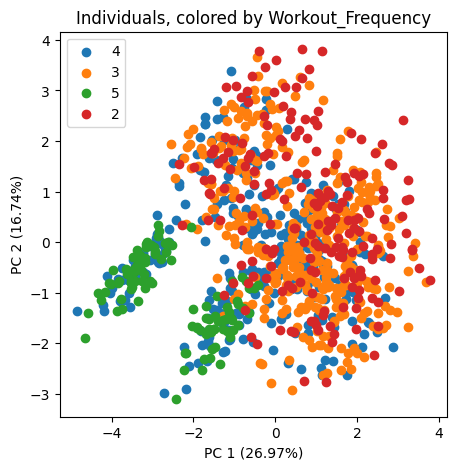

In [53]:
plt.figure(figsize=(5,5))
for freq in gym['Workout_Frequency'].unique():
    idx = gym['Workout_Frequency']==freq
    plt.scatter(X_pca[idx,0],X_pca[idx,1],label=freq)
plt.title("Individuals, colored by Workout_Frequency")
plt.xlabel(f"PC 1 ({100*experi[0]:.2f}%)")
plt.ylabel(f"PC 2 ({100*experi[1]:.2f}%)")
plt.legend()
plt.show()

**Comment:** People that go to gym 5 times a week stand of from the rest.

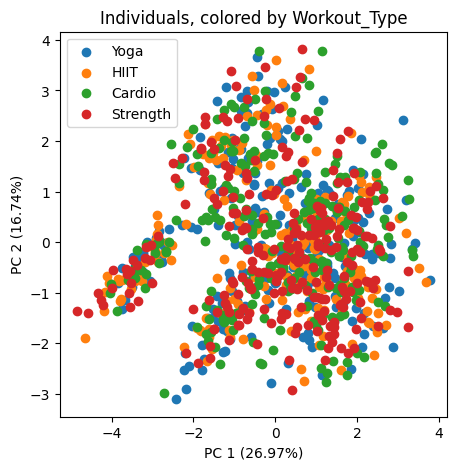

In [54]:
plt.figure(figsize=(5,5))
for type in gym['Workout_Type'].unique():
    idx = gym['Workout_Type']==type
    plt.scatter(X_pca[idx,0],X_pca[idx,1],label=type)
plt.title("Individuals, colored by Workout_Type")
plt.xlabel(f"PC 1 ({100*experi[0]:.2f}%)")
plt.ylabel(f"PC 2 ({100*experi[1]:.2f}%)")
plt.legend()
plt.show()

**Comment:** There is no visible separation of people according their workout types.

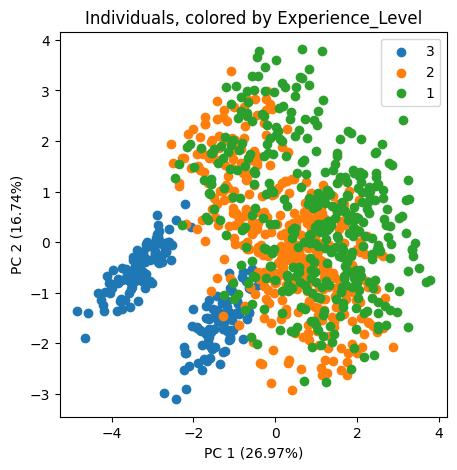

In [55]:
plt.figure(figsize=(5,5))
for exp in gym['Experience_Level'].unique():
    idx = gym['Experience_Level']==exp
    plt.scatter(X_pca[idx,0],X_pca[idx,1],label=exp)
plt.title("Individuals, colored by Experience_Level")
plt.xlabel(f"PC 1 ({100*experi[0]:.2f}%)")
plt.ylabel(f"PC 2 ({100*experi[1]:.2f}%)")
plt.legend()
plt.show()

**Comment:** People that have experience level 3 stand of from the rest, we also observe that most of these people go to gym 5 times a week.

### Representation of quantitative variables

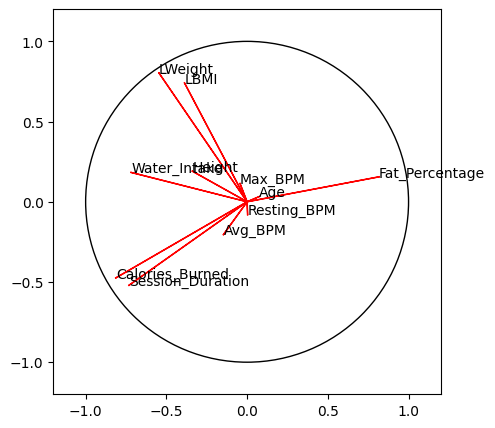

In [58]:
coord0 = pca.components_[0]*np.sqrt(pca.explained_variance_[0])
coord1 = pca.components_[1]*np.sqrt(pca.explained_variance_[1])
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1, 1, 1)
for i,j,nom in zip(coord0,coord1,quanti):
    plt.text(i,j,nom)
    plt.arrow(0,0,i,j,color='red')
plt.axis((-1.2,1.2,-1.2,1.2))
c=plt.Circle((0,0),radius=1.0,color='black',fill=False)
ax.add_patch(c)
plt.show()

**Remark**: We have 2 strongly correlated couples of variable, they are ('Lweight','LBMI') and ('Calories_Burned','Session_Duration'). We can consider removing one variable of each couple to lighten our data and optimize computational cost, without affecting the prediction quality.

# Calories Burned Prediction

## Training and test data splitting

In [59]:
gym.head()

,Age,Gender,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake,Workout_Frequency,Experience_Level,LBMI,LWeight
0,56,Male,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,3.407842,4.480740
1,46,Female,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,3.465736,4.316154
2,32,Female,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,3.207208,4.220977
3,25,Male,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,2.912894,3.974058
4,38,Male,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,2.666534,3.830813


In [60]:
gymDum = pd.get_dummies(gym,quali, drop_first=False, dtype=int)
del gymDum['Gender_Female']
gymDum.head()

,Age,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Calories_Burned,Fat_Percentage,Water_Intake,LBMI,...,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,Workout_Frequency_2,Workout_Frequency_3,Workout_Frequency_4,Workout_Frequency_5,Experience_Level_1,Experience_Level_2,Experience_Level_3
0,56,1.71,180,157,60,1.69,1313.0,12.6,3.5,3.407842,...,0,0,1,0,0,1,0,0,0,1
1,46,1.53,179,151,66,1.30,883.0,33.9,2.1,3.465736,...,1,0,0,0,0,1,0,0,1,0
2,32,1.66,167,122,54,1.11,677.0,33.4,2.3,3.207208,...,0,0,0,0,0,1,0,0,1,0
3,25,1.70,190,164,56,0.59,532.0,28.8,2.1,2.912894,...,0,1,0,0,1,0,0,1,0,0
4,38,1.79,188,158,68,0.64,556.0,29.2,2.8,2.666534,...,0,1,0,0,1,0,0,1,0,0


In [61]:
gymDum.columns

Index(['Age', 'Height', 'Max_BPM', 'Avg_BPM', 'Resting_BPM',
       'Session_Duration', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake',
       'LBMI', 'LWeight', 'Gender_Male', 'Workout_Type_Cardio',
       'Workout_Type_HIIT', 'Workout_Type_Strength', 'Workout_Type_Yoga',
       'Workout_Frequency_2', 'Workout_Frequency_3', 'Workout_Frequency_4',
       'Workout_Frequency_5', 'Experience_Level_1', 'Experience_Level_2',
       'Experience_Level_3'],
      dtype='object')

In [62]:
from sklearn.model_selection import train_test_split
X = gymDum.drop(columns=['Calories_Burned'])
y = gymDum['Calories_Burned']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

,Age,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Fat_Percentage,Water_Intake,LBMI,LWeight,...,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,Workout_Frequency_2,Workout_Frequency_3,Workout_Frequency_4,Workout_Frequency_5,Experience_Level_1,Experience_Level_2,Experience_Level_3
0,56,1.71,180,157,60,1.69,12.6,3.5,3.407842,4.480740,...,0,0,1,0,0,1,0,0,0,1
1,46,1.53,179,151,66,1.30,33.9,2.1,3.465736,4.316154,...,1,0,0,0,0,1,0,0,1,0
2,32,1.66,167,122,54,1.11,33.4,2.3,3.207208,4.220977,...,0,0,0,0,0,1,0,0,1,0
3,25,1.70,190,164,56,0.59,28.8,2.1,2.912894,3.974058,...,0,1,0,0,1,0,0,1,0,0
4,38,1.79,188,158,68,0.64,29.2,2.8,2.666534,3.830813,...,0,1,0,0,1,0,0,1,0,0


In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


print("Mean of X_train:", np.mean(X_train, axis=0))  # Should be close to 0
print("Variance of X_train:", np.var(X_train, axis=0))  # Should be close to 1

print('---------------------------------------------------------------------------')

print("Mean of X_test:", np.mean(X_test, axis=0))  
print("Variance of X_train:", np.var(X_test, axis=0))  

Mean of X_train: [ 3.65317602e-17 -4.56647002e-18 -2.28323501e-17  1.59826451e-17
 -3.88149952e-17  2.51155851e-17 -2.28323501e-17 -2.73988201e-17
  4.10982302e-17  0.00000000e+00 -2.51155851e-17  2.28323501e-18
 -6.39305803e-17 -3.65317602e-17 -1.94074976e-17  4.56647002e-17
  4.56647002e-17  2.28323501e-17 -1.14161751e-17 -2.85404377e-17
 -3.88149952e-17 -9.13294005e-18]
Variance of X_train: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
---------------------------------------------------------------------------
Mean of X_test: [ 0.02149282 -0.09860144  0.00869134  0.08530579  0.01260262  0.00699846
 -0.04525993 -0.10981037  0.12074845  0.06262187 -0.06953931 -0.07386357
 -0.03490885 -0.0678896   0.18441081  0.17233754 -0.1542879   0.00931974
  0.01171943  0.03490159 -0.08259218  0.06065624]
Variance of X_test: [1.01743396 0.88966563 0.97736897 0.95314065 0.91732623 1.18344727
 1.01622327 0.97096611 1.05691906 1.03122782 1.00412102 0.91743545
 0.95400541 0.925516


Before introducing the linear model, we are going to define a function to plot the coefficients chosen by every model.

In [65]:
def coeff_display(coef, X, title="Coefficients"):
    #X needs to be the dataframe used for train-test split
    fig, ax = plt.subplots(1,1,figsize=(8,5))
    coeff_series = pd.Series(coef, index = X.columns)
    coeff_series.plot(kind='barh', color='skyblue', edgecolor='black', ax=ax)
    ax.set_xlabel('Values')
    ax.set_ylabel('Categories')
    fig.suptitle(title)
    plt.tight_layout()
    return fig,ax

We are also going to define a function to plot the predicted values against the real values, and to plot the predicted values agains the residual values.

In [75]:
def plot_quant(model_name,fitted_model, X_test, y_test):
    y_pred = fitted_model.predict(X_test)
    
    fig,axs = plt.subplots(1,2,figsize=(10,5))
    axs[0].scatter(y_pred, y_test)
    axs[0].set_xlabel('Predicted Calories_Burn')
    axs[0].set_ylabel('Calories burned')
    axs[0].set_title('Predicted values v. real values')
    #add a diagonal line to LHS plot
    min_val = min(np.min(y_pred), np.min(y_test))
    max_val = max(np.max(y_pred), np.max(y_test))
    axs[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
    
    axs[1].scatter(y_pred, y_pred - y_test)
    axs[1].axhline(y=0.0,color='r',linestyle='-')
    axs[1].set_xlabel('Predicted Calories_Burned')
    axs[1].set_ylabel('Residus')
    axs[1].set_title('Predicted values v. residuals')
    plt.suptitle(model_name)
    plt.tight_layout()
    return fig, axs

We are also going to define a set of metrics used to evaluate the accuracy of our models. The include 
- the Mean Squared Error (MSE): $MSE = \frac{1}{n} \sum^{n}_{i=1}{(Y_i - \hat{Y}_i)^2}$
- the Mean Absolute Percentage Error (MAPE): $MAPE = \frac{1}{n} \sum^{n}_{i=1}{\frac{|Y_i - \hat{Y}_i|}{Y_i}}$
- the Residual Standard Error (RSE): $RSE = \sqrt{\frac{n \times MSE}{n-k-1}} = \sqrt{\frac{\sum^{n}_{i=1}{(Y_i-\hat{Y}_i)^2}}{n-k-1}}$
- the R2 score: $R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$,
  with $SS_{res} = \sum^{n}_{i=1}{(Y_i-\hat{Y}_i)^2}$,
  and $SS_{tot} = \sum^{n}_{i=1}{(Y_i-\bar{Y}^)2}$
- the adjusted R2 score: $R^2_{adj} = 1-\frac{(1-R^2)(n-1)}{n-k-1}$ with $n$ the number of individuals and $k$ the number of predictors
- the Akaike Information Criterion (AIC): $AIC = n \, \operatorname{ln}(MSE) + 2k$
- the Bayesian Information Criterion (BIC): $BIC = n \, \operatorname{ln}(MSE) + k \, \operatorname{ln}(n)$

We now have a heterogenous selection of criteria that are both sensitive to outliers (MSE & MAPE) and which penalizes complexity (adjusted R2, AIC, BIC), both (RSE), or neither (MSE). ALthough we would prefer to cross validate the different models on our data, this was deemed too time consuming, so we will base our model selection on the results obtained for these metrics. The train and test data has thus been fixed.

In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

def evaluate_linear_model(fitted_model, X_test, y_test):
    n = X_test.shape[0]
    y_pred = fitted_model.predict(X_test)
    k = 0 
    if hasattr(fitted_model, 'coef_'):
        k += np.count_nonzero(np.ravel(fitted_model.coef_))     
    if hasattr(fitted_model, 'intercept_'):
        k += np.count_nonzero(fitted_model.intercept_)
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rse = np.sqrt(n*mse/(n-k-1))
    r2 = r2_score(y_pred, y_test)
    adjR2 = 1-((1-r2)*(n-1)/(n-k-1))
    aic = n*np.log(mse) + 2*k
    bic = n*np.log(mse) + k*np.log(n)
    errors = {"MSE": mse, "MAPE": mape, "RSE": rse, "R2": r2, "adjR2": adjR2, "AIC": aic, "BIC": bic}
    return errors

We need a specific function to evalute SVR outputs.

In [68]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

def evaluate_svr_model(fitted_model, X_test, y_test):
    y_pred = fitted_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_pred, y_test)
    errors = {"MSE": mse, "MAPE": mape, "RSE": "N/A", "R2": r2, "adjR2": "N/A", "AIC": "N/A", "BIC": "N/A"}
    return errors

We need to adapt the 'evaluate_linear_model' to make it work for decision tree.

In [127]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

def evaluate_tree_model(fitted_model, X_test, y_test):
    n = X_test.shape[0]
    y_pred = fitted_model.predict(X_test)
    k = np.count_nonzero(fitted_model.feature_importances_)
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rse = np.sqrt(n*mse/(n-k-1))
    r2 = r2_score(y_pred, y_test)
    adjR2 = 1-((1-r2)*(n-1)/(n-k-1))
    aic = n*np.log(mse) + 2*k
    bic = n*np.log(mse) + k*np.log(n)
    errors = {"MSE": mse, "MAPE": mape, "RSE": rse, "R2": r2, "adjR2": adjR2, "AIC": aic, "BIC": bic}
    return errors

In [69]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train, y_train)

from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train, y_train)

df = pd.DataFrame(columns=["MSE", "MAPE", "RSE", "R2", "adjR2", "AIC", "BIC"])
df.loc["linreg"] = evaluate_linear_model(linreg, X_test, y_test)
df.loc["svr"] = evaluate_svr_model(svr, X_test, y_test)

In [70]:
df

,MSE,MAPE,RSE,R2,adjR2,AIC,BIC
linreg,1685.913042,0.037071,43.846692,0.979341,0.976563,1494.862199,1570.141189
svr,72668.457793,0.282632,N/A,-129.176771,N/A,N/A,N/A


The function seems to work well, we will apply it subsequentially.

In [71]:
quantmodels_log = pd.DataFrame(columns=["MSE", "MAPE", "RSE", "R2", "adjR2", "AIC", "BIC"])

## Linear Model

### Without Regularization

In [81]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

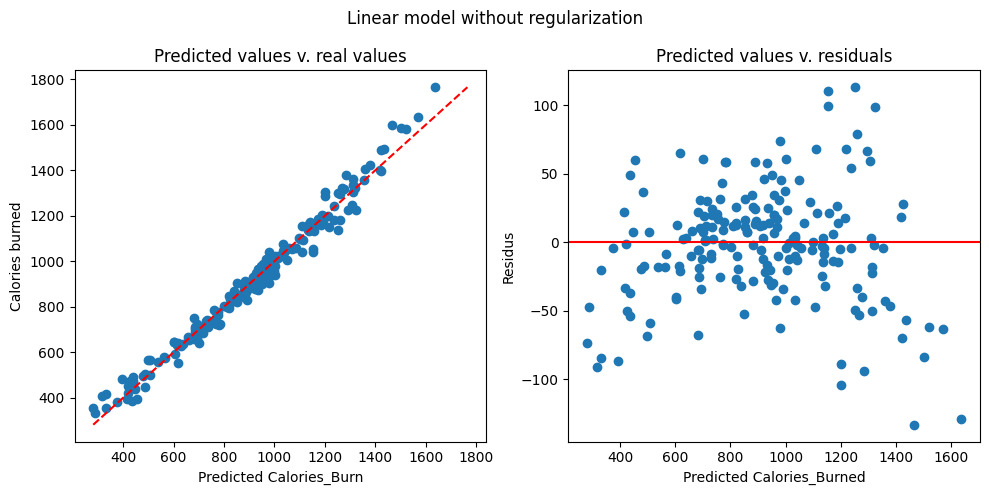

In [82]:
fig,Axs = plot_quant("Linear model without regularization",reg, X_test, y_test)
plt.show()

In [83]:
quantmodels_log.loc["Lin reg"] = evaluate_linear_model(reg, X_test, y_test)
print(quantmodels_log.round(2))

             MSE  MAPE    RSE    R2  adjR2      AIC      BIC
Lin reg  1685.91  0.04  43.85  0.98   0.98  1494.86  1570.14


**Comment**: The result is really good, the linear model performed reasonably well on the test set. The predicted values are quite close to the real values as the cloud of points on the 'predicted values vs real values' graph are situated on the diagonal. However, the residuals do not seem to be independent (banana form) and rather seem to depend on the predicted values. The observations do not meet the gaussian assumption of regression model.

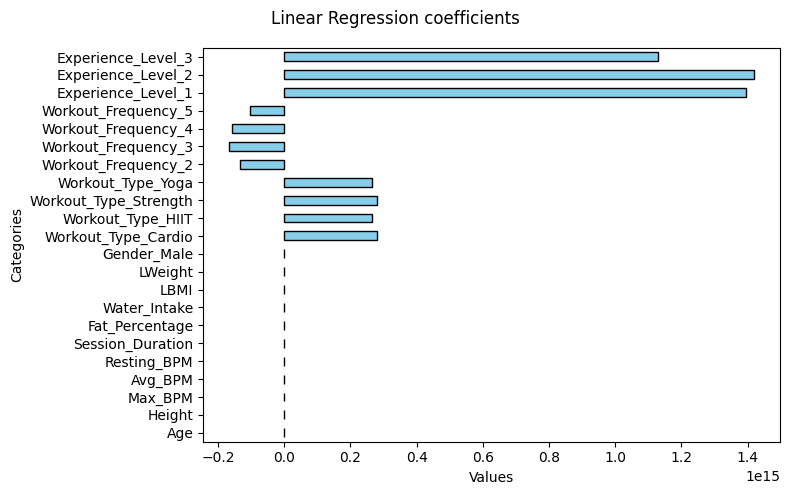

In [84]:
fig, Axs = coeff_display(reg.coef_, X, "Linear Regression coefficients")
plt.show()

**Comments:**
- Basing on the absolute values of coefficients, The variable Session_Duration, Avg_BPM, Gender, Age, Fat_percentage and Resting_BMP columns are significant to the predicted values of calories burned.
The experience level, workout frequency have very low impact in the predicted values of calories burned although the multi-dimensional analysis above suggests that there are strong correlations between experience level, workout frequency and calories burned. Possible reason for this counter-intuitive observation is that the information of experience level, workout frequency may be included in others variables such as session duration, Avg_BPM.
- On the other hand, age is weakly correlated with calories burned but its coefficient is significative, in sense of absolute value, this observation need to be explain.

### With Regularization

#### Lasso

In [88]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

param=[{"alpha":[0.05,0.1,0.2,0.3,0.4,0.5,1,1.2,1.4,1.6,1.8,2.0]}]
reg_lasso = GridSearchCV(Lasso(),param,cv=10,n_jobs=-1)
reg_lasso_opt = reg_lasso.fit(X_train, y_train)

# Optimal parameters
print(f"Best R2 score obtained: {reg_lasso_opt.best_score_:.2f}")
print(f"Best value for alpha:   {reg_lasso_opt.best_params_['alpha']:.2f}")

Best R2 score obtained: 0.98
Best value for alpha:   1.20


In [89]:
reg_lasso_opt = Lasso(alpha=1.20).fit(X_train, y_train) #we reconstruct the model object

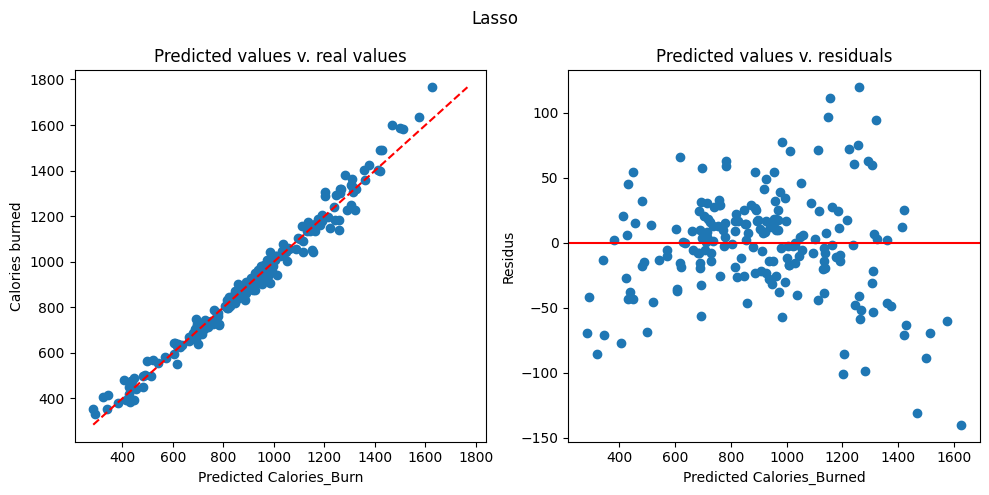

In [91]:
fig,Axs = plot_quant("Lasso",reg_lasso_opt, X_test, y_test)
plt.show()

In [92]:
quantmodels_log.loc["Lasso"] = evaluate_linear_model(reg_lasso_opt, X_test, y_test)
print(quantmodels_log.round(2))

             MSE  MAPE    RSE    R2  adjR2      AIC      BIC
Lin reg  1685.91  0.04  43.85  0.98   0.98  1494.86  1570.14
Lasso    1635.91  0.04  42.10  0.98   0.98  1470.99  1516.81


**Comment**: Basing on the mean squared erros and R2 score, the lasso model performs slightly better than linear model without regularization. However, the bad observation on the residuals still persists.

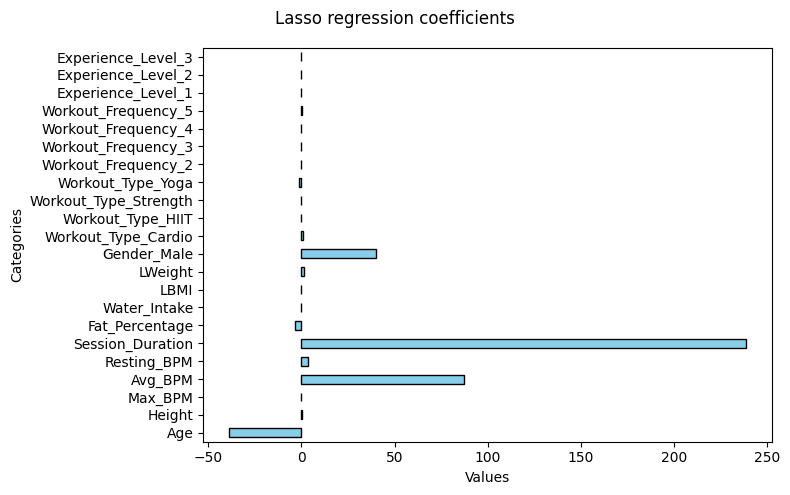

In [93]:
fig, Axs = coeff_display(reg_lasso_opt.coef_, X, title="Lasso regression coefficients")
plt.show()

**Comment:** The coefficients of the Lasso regression model are very similar to the ones observed for the non-regularized linear regression model. The main differance is that the low values observed under no regularization are even lower for the Lasso model. This is coherent with the nature of the L1 penalization. 

#### L2 Regularization

In [95]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

param=[{"alpha":np.arange(0.2, 10, 0.2)}]
reg_ridge = GridSearchCV(Ridge(),param,cv=10,n_jobs=-1)
reg_ridge_opt = reg_ridge.fit(X_train, y_train)

# Optimal parameters
print(f"Best R2 score obtained: {reg_ridge.best_score_:.2f}")
print(f"Best value for alpha:   {reg_ridge_opt.best_params_['alpha']:.2f}")

Best R2 score obtained: 0.98
Best value for alpha:   1.00


In [96]:
reg_ridge_opt = Ridge(alpha=1.00).fit(X_train, y_train) #we reconstruct the model object

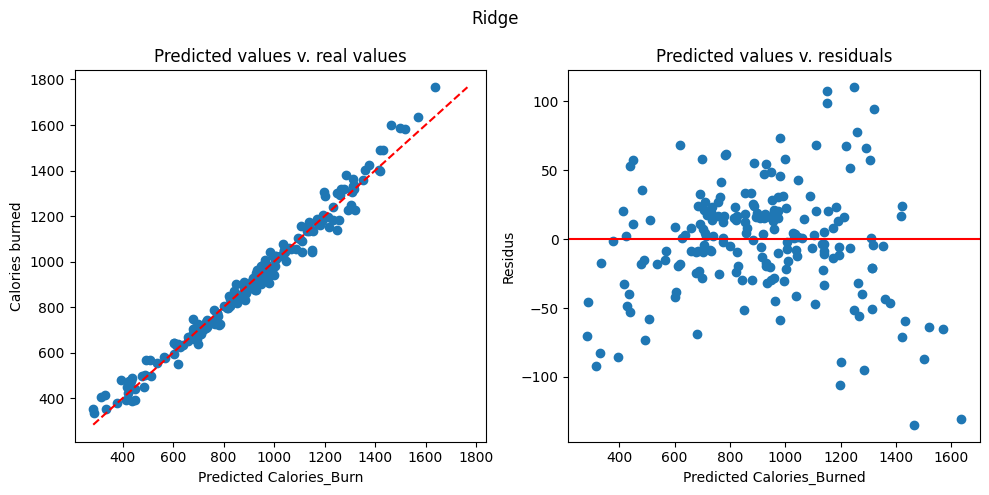

In [98]:
fig, Axs = plot_quant("Ridge",reg_ridge_opt, X_test, y_test)
plt.show()

In [99]:
quantmodels_log.loc["Ridge"] = evaluate_linear_model(reg_ridge_opt, X_test, y_test)
print(quantmodels_log.round(2))

             MSE  MAPE    RSE    R2  adjR2      AIC      BIC
Lin reg  1685.91  0.04  43.85  0.98   0.98  1494.86  1570.14
Lasso    1635.91  0.04  42.10  0.98   0.98  1470.99  1516.81
Ridge    1669.13  0.04  43.63  0.98   0.98  1492.91  1568.19


**Comments**: 
- Visually, we observe about the same results as for the previous models (non-regularized linear regression, lasso regression)
- The ridge seems to perform worse than both of the previous models, most likely because it has the characteristic of keeping variables that have low importance

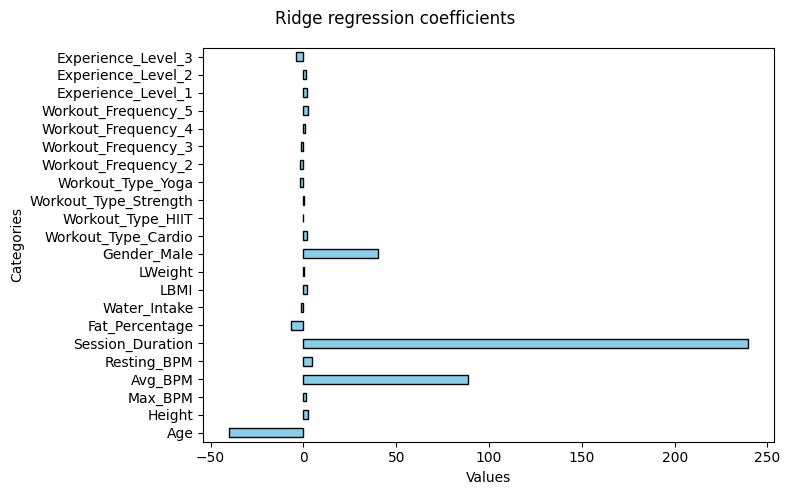

In [100]:
fig, Axs = coeff_display(reg_ridge_opt.coef_, X, title="Ridge regression coefficients")
plt.show()

## Support Vector Regression

We are now going to optimise and test the Support Vector Regression model. We are going to avoid optimising the 'kernel' hyperparameter and instead test all the different kernels to see how they perform. 

### Linear Kernel

In [102]:
from sklearn.svm import SVR

param={"C":np.linspace(459,461,10),
       "epsilon":np.linspace(2.0,2.2,10),
       "kernel":['linear']}

linear_svr = GridSearchCV(SVR(),param,cv=10,n_jobs=-1)
linear_svr_opt = linear_svr.fit(X_train, y_train)


# Optimal parameters
print("linear kernel svr")
print(f"Best R2 score obtained: {linear_svr_opt.best_score_:.2f}")
print(f"Best value for C:       {linear_svr_opt.best_params_['C']:.2f}")
print(f"Best value for eps:     {linear_svr_opt.best_params_['epsilon']:.2f}")

KeyboardInterrupt: 

In [103]:
linear_svr_opt = SVR(C=459.22, epsilon=2.0, kernel="linear").fit(X_train, y_train) #we reconstruct the model

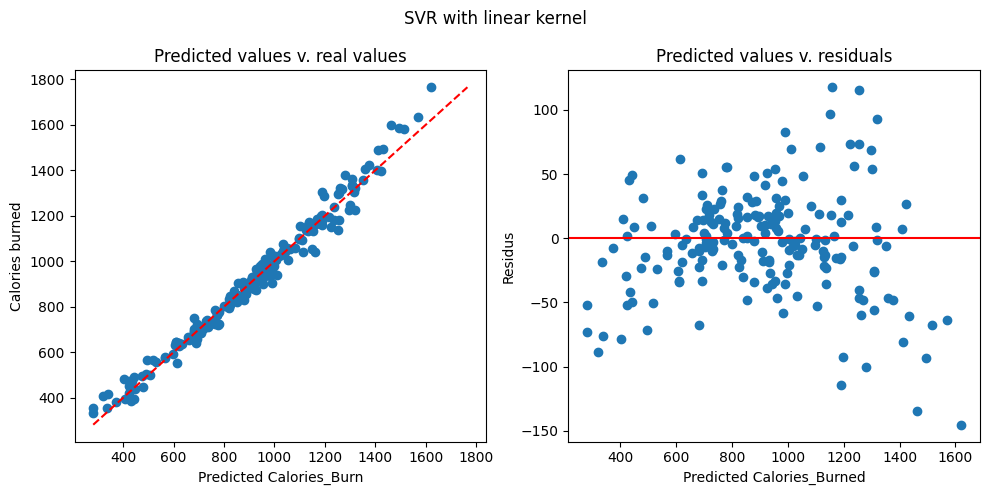

In [105]:
fig, Axs = plot_quant("SVR with linear kernel",linear_svr_opt, X_test, y_test)
plt.show()

In [108]:
quantmodels_log.loc["Linear SVR"] = evaluate_svr_model(linear_svr_opt, X_test, y_test)
print(quantmodels_log.round(4))

                  MSE    MAPE        RSE      R2     adjR2          AIC  \
Lin reg     1685.9130  0.0371  43.846692  0.9793  0.976563  1494.862199   
Lasso       1635.9135  0.0356  42.097977  0.9797  0.978119  1470.991551   
Ridge       1669.1280  0.0370  43.627876  0.9794   0.97668  1492.911036   
Linear SVR  1731.1750  0.0366        N/A  0.9786       N/A          N/A   

                    BIC  
Lin reg     1570.141189  
Lasso       1516.813545  
Ridge       1568.190026  
Linear SVR          N/A  


**Comments:**
- We see that the Linear Kernel Support Vector Regression-model performs notably worse on the MSE criterion.
- Because the model does not nullify any parameters it is also a worse performer as measured by the AIC and BIC criteria.

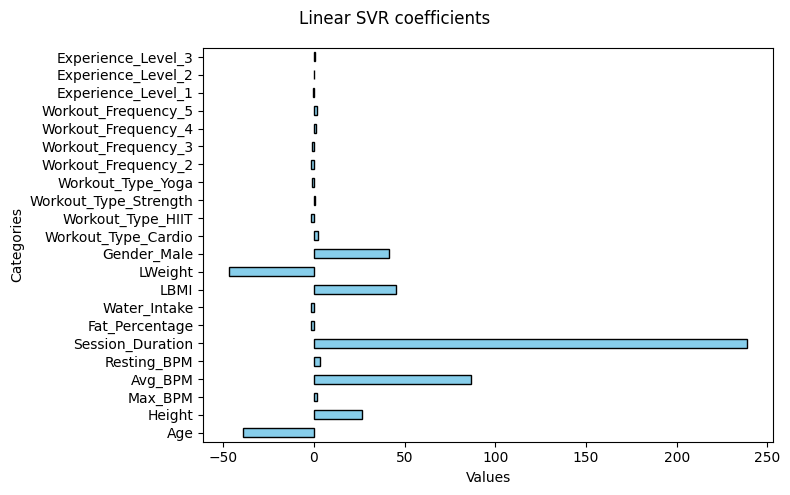

In [109]:
fig, ax = coeff_display(linear_svr_opt.coef_[0,:], X, title="Linear SVR coefficients")
plt.show()

**Comments:**
- The model instills a lot of importance in 'LBMI' and 'Avg_BPM'

### Polynomial Kernel

In [110]:
from sklearn.svm import SVR

param={"C":np.linspace(400,500,20),
       "epsilon":np.linspace(10,50,5),
       "degree":[1,2,3,4],
       "kernel":['poly']}

polynomial_svr = GridSearchCV(SVR(), param, cv=10, n_jobs=-1)
polynomial_svr_opt = polynomial_svr.fit(X_train, y_train)


# Optimal parameters
print("polynomial kernel svr")
print(f"Best R2 score obtained: {polynomial_svr_opt.best_score_:.2f}")
print(f"Best value for C:       {polynomial_svr_opt.best_params_["C"]:.2f}")
print(f"Best value for eps:     {polynomial_svr_opt.best_params_["epsilon"]:.2f}")
print(f"Best value for degree:  {polynomial_svr_opt.best_params_["degree"]:d}")

SyntaxError: f-string: unmatched '[' (946735001.py, line 15)

In [111]:
polynomial_svr_opt = SVR(C=473.68, epsilon=40, degree=1, kernel="poly").fit(X_train, y_train) #we reconstruct the model

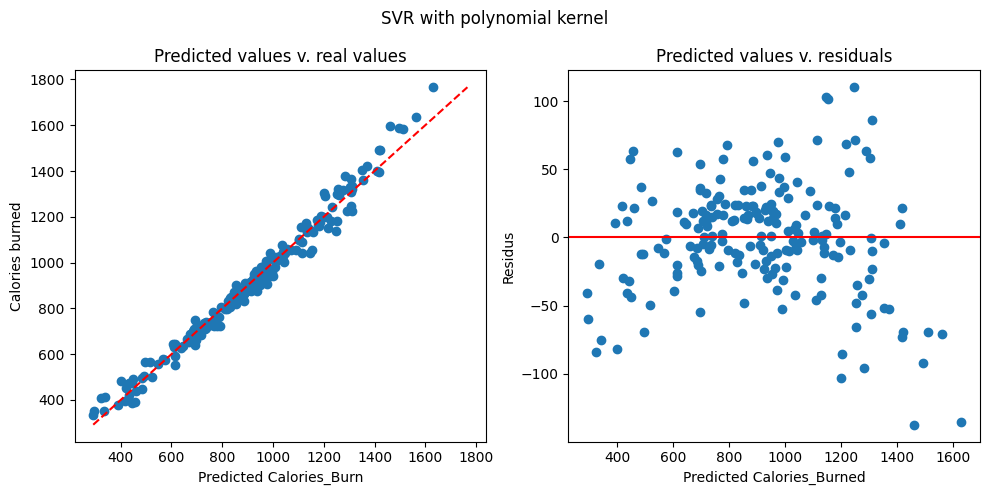

In [113]:
fig, Axs = plot_quant("SVR with polynomial kernel",polynomial_svr_opt, X_test, y_test)
plt.show()

In [115]:
quantmodels_log.loc["Polynomial SVR"] = evaluate_svr_model(polynomial_svr_opt, X_test, y_test)
print(quantmodels_log.round(2))

                    MSE  MAPE        RSE    R2     adjR2          AIC  \
Lin reg         1685.91  0.04  43.846692  0.98  0.976563  1494.862199   
Lasso           1635.91  0.04  42.097977  0.98  0.978119  1470.991551   
Ridge           1669.13  0.04  43.627876  0.98   0.97668  1492.911036   
Linear SVR      1731.17  0.04        N/A  0.98       N/A          N/A   
Polynomial SVR  1651.15  0.04        N/A  0.98       N/A          N/A   

                        BIC  
Lin reg         1570.141189  
Lasso           1516.813545  
Ridge           1568.190026  
Linear SVR              N/A  
Polynomial SVR          N/A  


**Comment:** It seems that the polynomial kernel support vector regression performs a bit better than the linear kernel support vector regression. It is on par with the linear regression methods.


We cannot plot the coefficients for the SVR model with polynomial kernel. However, we can try to extract the importance using a permutation approach.

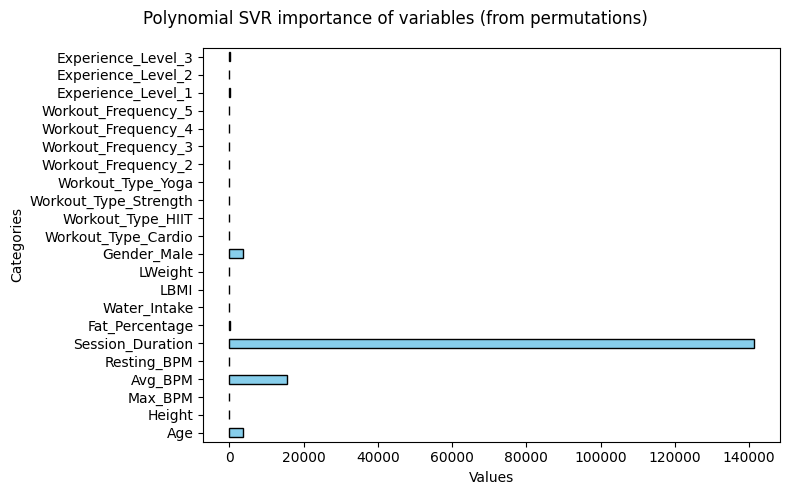

In [116]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
results = permutation_importance(polynomial_svr_opt, X_test, y_test, 
                                scoring='neg_mean_squared_error', 
                                n_repeats=10, 
                                random_state=42)

# Extract importance scores
fig,ax = coeff_display(results.importances_mean, X, title="Polynomial SVR importance of variables (from permutations)")
plt.show()

**Comment:** Based on the observed results from the permutations method, we see that the polynomial kernel support vector regression model mostly prioritizes the 'Session_Duration', 'Gender_Male', 'Avg_BPM', and 'Age' variables

### Radial Kernel

In [117]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

param= {
    'C': np.arange(900, 1100, 10),
    'gamma': [0.0001, 0.001, 0.01, 0.02, 0.05, 0.1, 1],
    'epsilon': [0.01, 0.1, 0.2, 0.5, 1],
    'kernel': ['rbf']}

radial_svr = GridSearchCV(SVR(), param, cv=10, n_jobs=-1)
radial_svr_opt = radial_svr.fit(X_train, y_train)


# Optimal parameters
print("radial kernel svr")
print(f"Best R2 score obtained: {radial_svr_opt.best_score_:.2f}")
print(f"Best value for C:       {radial_svr_opt.best_params_["C"]:.2f}")
print(f"Best value for eps:     {radial_svr_opt.best_params_["epsilon"]:.2f}")
print(f"Best value for gamma:   {radial_svr_opt.best_params_["gamma"]:.2f}")

SyntaxError: f-string: unmatched '[' (4038317139.py, line 17)

In [118]:
radial_svr_opt = SVR(C=1000, epsilon=0.01, gamma=0.01, kernel='rbf').fit(X_train, y_train) #we reconstruct the SVR model

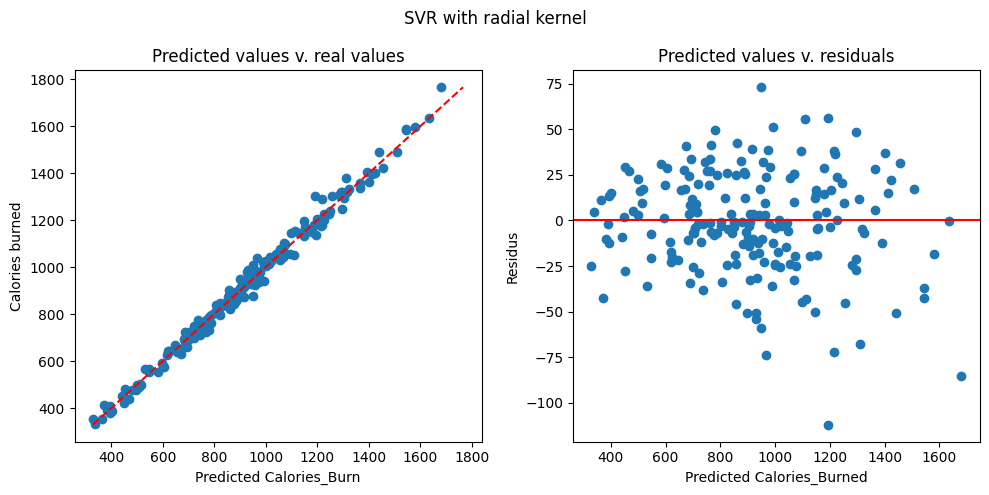

In [120]:
fig, Axs = plot_quant("SVR with radial kernel",radial_svr_opt, X_test, y_test)
plt.show()

In [121]:
quantmodels_log.loc["Radial SVR"] = evaluate_svr_model(radial_svr_opt, X_test, y_test)
print(quantmodels_log.round(4))

                      MSE    MAPE        RSE      R2     adjR2          AIC  \
Lin reg         1685.9130  0.0371  43.846692  0.9793  0.976563  1494.862199   
Lasso           1635.9135  0.0356  42.097977  0.9797  0.978119  1470.991551   
Ridge           1669.1280  0.0370  43.627876  0.9794   0.97668  1492.911036   
Linear SVR      1731.1750  0.0366        N/A  0.9786       N/A          N/A   
Polynomial SVR  1651.1468  0.0370        N/A  0.9793       N/A          N/A   
Radial SVR       782.2434  0.0248        N/A  0.9903       N/A          N/A   

                        BIC  
Lin reg         1570.141189  
Lasso           1516.813545  
Ridge           1568.190026  
Linear SVR              N/A  
Polynomial SVR          N/A  
Radial SVR              N/A  


**Comment:** The radial kernel outperforms both the other support vector models, and the linear models by a long shot. However, such models often have a relatively high complexity as opposed to the linear models. The linear regression models are most likely more performant when evaluating using metrics penalizing complexity.

Once again, we cannot plot the coefficients for this model, so we will use the permutations method.

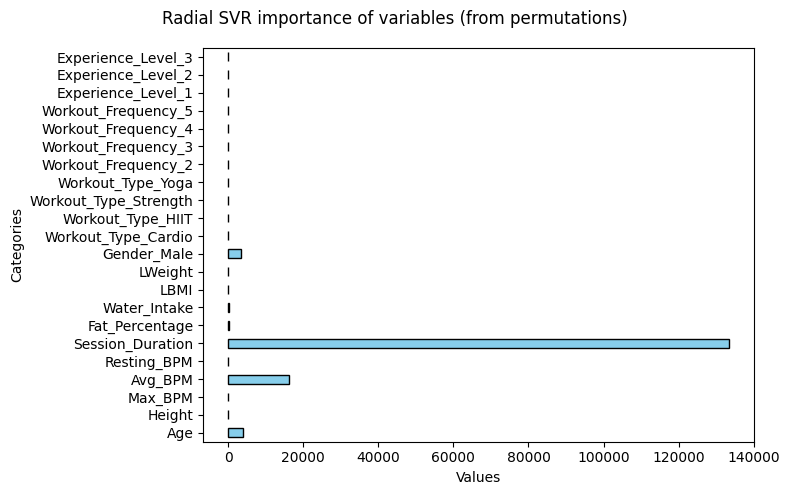

In [205]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
results = permutation_importance(radial_svr_opt, X_test, y_test, 
                                scoring='neg_mean_squared_error', 
                                n_repeats=10, 
                                random_state=42)

# Extract importance scores
fig,ax = coeff_display(results.importances_mean, X, title="Radial SVR importance of variables (from permutations)")
plt.show()

**Comment:** It seems the radial kernel support vector regression model instills importance into the variables in about the same way as the polynomial kernel method.

## Regression Tree

In this part of the notebook, we are going to use a regression tree to predict the value for 'Calories_Burned'.

In [129]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

params={"criterion": ["squared_error", "friedman_mse", "absolute_error", "poisson"],
         "splitter": ["best", "random"],
         "max_depth": [None, 5, 6, 7, 8],
         "min_samples_split": [2, 3, 4, 5],
         "min_samples_leaf": [2, 3, 4, 5],
         "max_features": [None, "sqrt", "log2"],
         'max_leaf_nodes': [None, 10, 20, 50],
         "random_state": [2]
        }
reg_tree = GridSearchCV(DecisionTreeRegressor(), params, cv=10, n_jobs=-1)
reg_tree_opt = reg_tree.fit(X_train, y_train)

# Optimal parameters
print("Best tree:")
print("-----------------")
print(f" - criterion=         {reg_tree_opt.best_params_["criterion"]}")
print(f" - splitter=          {reg_tree_opt.best_params_["splitter"]}")
print(f" - max_depth=         {reg_tree_opt.best_params_["max_depth"]}")
print(f" - min_samples_split= {reg_tree_opt.best_params_["min_samples_split"]}")
print(f" - min_samples_leaf=  {reg_tree_opt.best_params_["min_samples_leaf"]}")
print(f" - max_features=      {reg_tree_opt.best_params_["max_features"]}")
print(f" - max_leaf_nodes=    {reg_tree_opt.best_params_["max_leaf_nodes"]}")

# we save the optimal parametrs

criterion_opt = reg_tree_opt.best_params_["criterion"]
splitter_opt = reg_tree_opt.best_params_["splitter"]
max_depth_opt = reg_tree_opt.best_params_["max_depth"]
min_samples_split_opt = reg_tree_opt.best_params_["min_samples_split"]
min_samples_leaf_opt = reg_tree_opt.best_params_["min_samples_leaf"]
max_features_opt = reg_tree_opt.best_params_["max_features"]
max_leaf_nodes_opt = reg_tree_opt.best_params_["max_leaf_nodes"]

Best tree:
-----------------
 - criterion=         squared_error
 - splitter=          best
 - max_depth=         None
 - min_samples_split= 5
 - min_samples_leaf=  2
 - max_features=      None
 - max_leaf_nodes=    None


In [123]:


reg_tree_opt = DecisionTreeRegressor(criterion='squared_error',
                                     splitter='best',
                                     max_depth=None,
                                     min_samples_split=5,
                                     min_samples_leaf=2,
                                     max_features=None,
                                     max_leaf_nodes=None,
                                     random_state=2) # we remake the tree
reg_tree_opt.fit(X_train, y_train)

DecisionTreeRegressor(min_samples_leaf=2, min_samples_split=5, random_state=2)

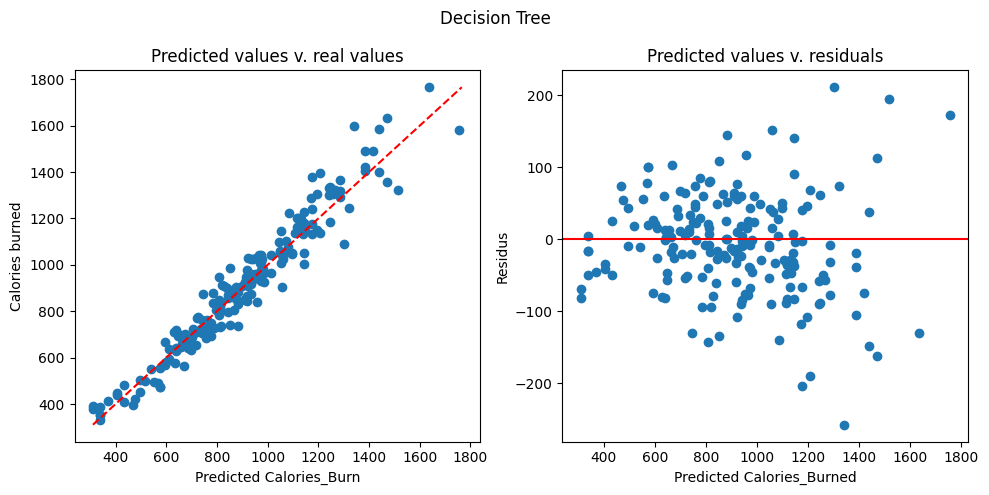

In [125]:
fig, Axs = plot_quant("Decision Tree",reg_tree_opt, X_test, y_test)
plt.show()

In [128]:
pd.set_option('display.width', 1000)
quantmodels_log.loc["Dec tree"] = evaluate_tree_model(reg_tree_opt, X_test, y_test)
print(quantmodels_log.round(4))

                      MSE    MAPE        RSE      R2     adjR2          AIC          BIC
Lin reg         1685.9130  0.0371  43.846692  0.9793  0.976563  1494.862199  1570.141189
Lasso           1635.9135  0.0356  42.097977  0.9797  0.978119  1470.991551  1516.813545
Ridge           1669.1280  0.0370  43.627876  0.9794   0.97668  1492.911036  1568.190026
Linear SVR      1731.1750  0.0366        N/A  0.9786       N/A          N/A          N/A
Polynomial SVR  1651.1468  0.0370        N/A  0.9793       N/A          N/A          N/A
Radial SVR       782.2434  0.0248        N/A  0.9903       N/A          N/A          N/A
Dec tree        4895.7232  0.0604  73.859559  0.9345  0.927363   1694.74287  1756.929862


**Comment:** The tree seems to perform rather poorly, most likely because it can only choose among a restricted number of values to predict (the leaf-means).

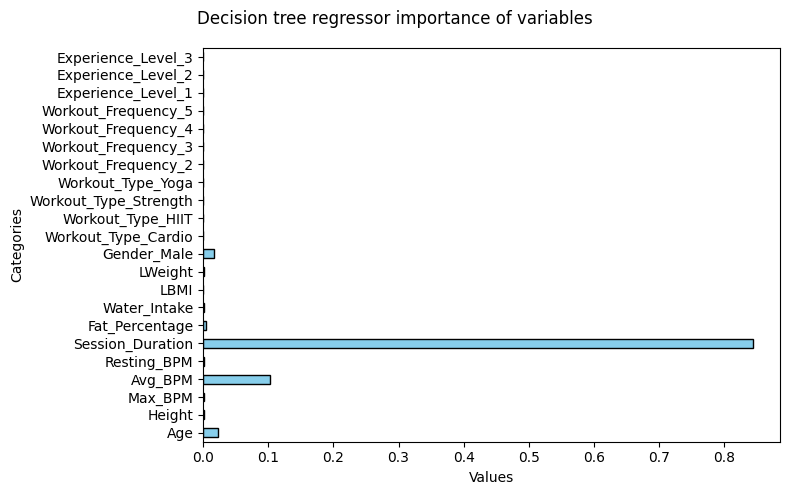

In [129]:
fig,ax = coeff_display(reg_tree_opt.feature_importances_, X, title="Decision tree regressor importance of variables")
plt.show()

**Comment:** Similarily to the previous models, the decision tree regressor instills the most importance to 'Session_Duration', 'Avg_BPM', 'Gender_Male', and 'Age'

Specifically for the decision tree, we can visualize the prediction by plotting the nodes.

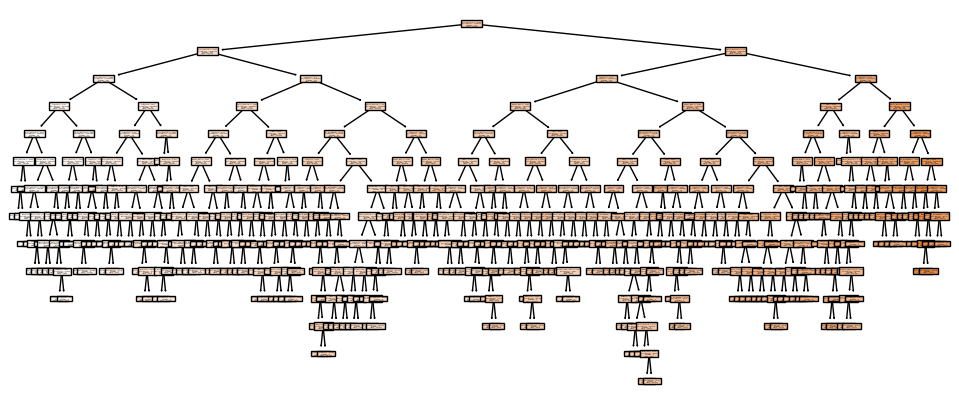

In [130]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(1,1,figsize=(12,5))
plot_tree(reg_tree_opt, feature_names=X.columns, filled=True, ax=ax)
plt.show()

**Remark:** Wow, that is a lot of nodes. We will try the 'SuperTree' libarary to create a 

In [240]:
from supertree import SuperTree
from sklearn.preprocessing import LabelEncoder


label_encoder = LabelEncoder()
reg_tree_opt = DecisionTreeRegressor(criterion=criterion_opt,
                                     splitter=splitter_opt,
                                     max_depth=max_depth_opt,
                                     min_samples_split=min_samples_split_opt,
                                     min_samples_leaf=min_samples_leaf_opt,
                                     max_features=max_features_opt,
                                     max_leaf_nodes=max_leaf_nodes_opt,
                                     random_state=2) # we remake the tree

y_train_encoded = label_encoder.fit_transform(y_train)
reg_tree_opt.fit(X_train, y_train_encoded)
supertree = SuperTree(reg_tree_opt, X_train, y_train_encoded, feature_names = X.columns.to_list())
supertree.show_tree() #uncomment to show plot

## Random Forest Regression

We will try a semi-optimised approach, using the same hyper parameters as found for the decision tree, and only optimising on the new hyper parameters inherent to the random forest method.

In [246]:
from sklearn.ensemble import RandomForestRegressor


param = {"n_estimators": [10, 50, 100, 200, 500, 600],
         "criterion": [criterion_opt],
         "max_depth": [max_depth_opt],
         "min_samples_split": [min_samples_split_opt],
         "min_samples_leaf": [min_samples_leaf_opt],
         "max_features": [max_features_opt],
         'max_leaf_nodes': [max_leaf_nodes_opt],
         "bootstrap": [True, False],
         "random_state": [2]
        } #same as for decision tree

reg_random_forest = GridSearchCV(RandomForestRegressor(),param,cv=10,n_jobs=-1)
reg_random_forest_opt = reg_random_forest.fit(X_train,y_train)


# Optimal parameters
print("Semi-optimised forest:")
print("-----------------")
print(f" - r2 score obtained=  {reg_random_forest_opt.best_score_:.2f}")
print(f" - criterion=          {reg_random_forest_opt.best_params_["criterion"]}")
print(f" - max_depth=          {reg_random_forest_opt.best_params_["max_depth"]}")
print(f" - min_samples_split=  {reg_random_forest_opt.best_params_["min_samples_split"]}")
print(f" - min_samples_leaf=   {reg_random_forest_opt.best_params_["min_samples_leaf"]}")
print(f" - max_features=       {reg_random_forest_opt.best_params_["max_features"]}")
print(f" - max_leaf_nodes=     {reg_random_forest_opt.best_params_["max_leaf_nodes"]}")
print(f" - n_estimators [NEW]= {reg_random_forest_opt.best_params_["n_estimators"]}")
print(f" - bootstrap [NEW]=    {reg_random_forest_opt.best_params_["bootstrap"]}")

# we save the optimal parametrs
n_estimators_opt = reg_random_forest_opt.best_params_["n_estimators"]
bootstrap_opt = reg_random_forest_opt.best_params_["bootstrap"]

Semi-optimised forest:
-----------------
 - r2 score obtained=  0.97
 - criterion=          squared_error
 - max_depth=          None
 - min_samples_split=  5
 - min_samples_leaf=   2
 - max_features=       None
 - max_leaf_nodes=     None
 - n_estimators [NEW]= 600
 - bootstrap [NEW]=    True


In [136]:
from sklearn.ensemble import RandomForestRegressor

reg_random_forest_opt = RandomForestRegressor(criterion='squared_error',
                                              max_depth=None,
                                              min_samples_split=5,
                                              min_samples_leaf=2,
                                              max_features=None,
                                              max_leaf_nodes=None,
                                              n_estimators=600,
                                              bootstrap=True) #reconstruction
reg_random_forest_opt.fit(X_train, y_train)

RandomForestRegressor(max_features=None, min_samples_leaf=2,
                      min_samples_split=5, n_estimators=600)

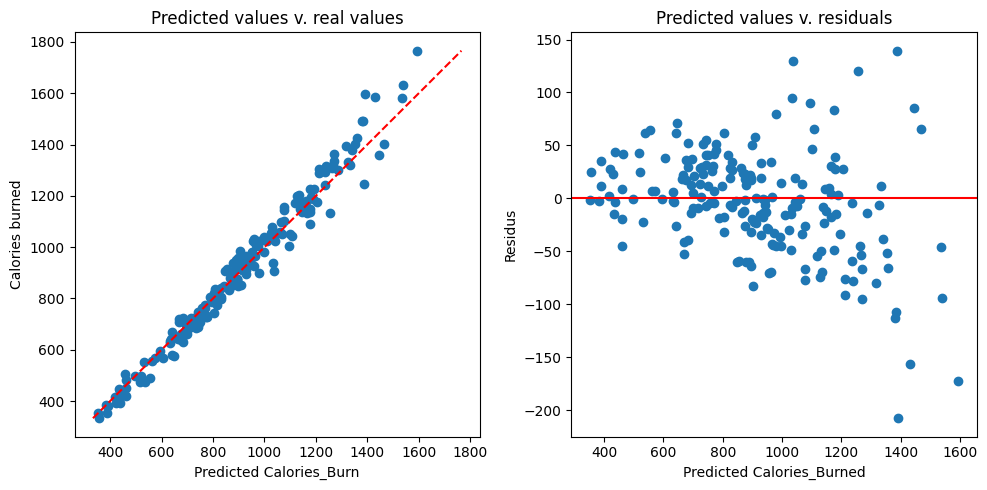

In [252]:
fig, Axs = plot_quant(reg_random_forest_opt, X_test, y_test)
plt.show()

In [137]:
pd.set_option('display.width',1000)
quantmodels_log.loc["Rand forest"] = evaluate_tree_model(reg_random_forest_opt, X_test, y_test)
print(quantmodels_log.round(2))

                    MSE  MAPE        RSE    R2     adjR2          AIC          BIC
Lin reg         1665.44  0.04  43.579684  0.98  0.976795  1492.479998  1567.758988
Lasso           1635.91  0.04  42.097977  0.98  0.978119  1470.991551  1516.813545
Ridge           1669.13  0.04  43.627876  0.98   0.97668  1492.911036  1568.190026
Linear SVR      1731.17  0.04        N/A  0.98       N/A          N/A          N/A
Polynomial SVR  1651.15  0.04        N/A  0.98       N/A          N/A          N/A
Radial SVR       782.24  0.02        N/A  0.99       N/A          N/A          N/A
Dec tree        4895.72  0.06  73.859559  0.93  0.927363   1694.74287  1756.929862
Rand forest     2368.69  0.04  51.821138  0.97  0.962911   1559.16778   1631.17377


**Comment:** the results obtained for the random forest are a lot better than those obtained for the decision tree, but both methods remain less performant in terms of our criteria than the support vector machine or linear regression models.

#### Full optimised Random Forest Regression

In [263]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV #should reduce optimisation time

param = {"n_estimators": [600], #we restrain the number of estimators. trial and errors shows 600 to fit
         "criterion": ["squared_error"], #no reason to change criterion
         "max_depth": [None, 5, 6, 7, 8],
         "min_samples_split": [2, 3, 4, 5],
         "min_samples_leaf": [2, 3, 4, 5],
         "max_features": [None, "sqrt", "log2"],
         'max_leaf_nodes': [None, 10, 20, 50],
         "bootstrap": [True, False],
         "random_state": [2]
        } #optimising almost every parameter

full_reg_random_forest = HalvingGridSearchCV(RandomForestRegressor(),param,cv=10,n_jobs=-1)
full_reg_random_forest_opt = full_reg_random_forest.fit(X_train,y_train)

# Optimal parameters
print("Full-optimised forest:")
print("-----------------")
print(f" - r2 score obtained=  {reg_random_forest.best_score_:.2f}")
print(f" - criterion=          {reg_random_forest.best_params_["criterion"]}")
print(f" - max_depth=          {reg_random_forest.best_params_["max_depth"]}")
print(f" - min_samples_split=  {reg_random_forest.best_params_["min_samples_split"]}")
print(f" - min_samples_leaf=   {reg_random_forest.best_params_["min_samples_leaf"]}")
print(f" - max_features=       {reg_random_forest.best_params_["max_features"]}")
print(f" - max_leaf_nodes=     {reg_random_forest.best_params_["max_leaf_nodes"]}")
print(f" - n_estimators [NEW]= {reg_random_forest.best_params_["n_estimators"]}")
print(f" - bootstrap [NEW]=    {reg_random_forest.best_params_["bootstrap"]}")

Full-optimised forest:
-----------------
 - r2 score obtained=  0.97
 - criterion=          squared_error
 - max_depth=          None
 - min_samples_split=  5
 - min_samples_leaf=   2
 - max_features=       None
 - max_leaf_nodes=     None
 - n_estimators [NEW]= 600
 - bootstrap [NEW]=    True


**Remark:** We find the same hyperparameters as we did when reusing the decision tree hyperparameters + optimising the 'bootstrap' and 'n_estimators' hyperparameters. We will remember this when optimising the Random Forest Classifier model, as this can help us save a lot of time.

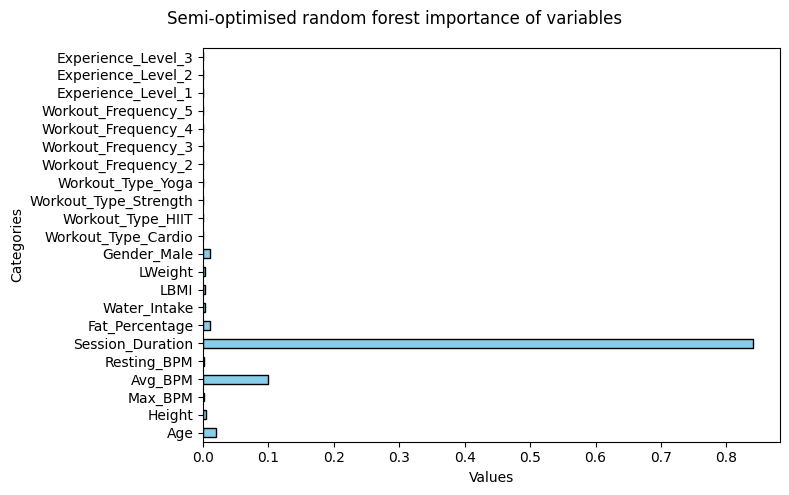

In [268]:
fig, ax = coeff_display(reg_random_forest_opt.feature_importances_, X, title="Semi-optimised random forest importance of variables")
plt.show()

**Comment:** We see that the Random Forest allocates a lot of importance to the 'Session_Duration'. Contrary to the previous models, it instill very little importance to the 'Gender_Male' variable.

## AdaBoosting Regression

Before running the main optimisation program, we want to determine which 'max_depth' is the most suitable for our AdaBoost regressor's weak-learner (here: a DecisionTreeRegressor). This is an import parameter to optimise, because AdaBoost looses it's purpose if the weak-learner is too precise, but looses also looses precision if the weak-learner is too imprecise.

In [131]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

depths = np.arange(1,11,1)
scores = []
for depth in depths:
    base = DecisionTreeRegressor(max_depth=depth)
    model = AdaBoostRegressor(base, n_estimators=100)
    score = cross_val_score(model, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
    scores.append(-score.mean())    

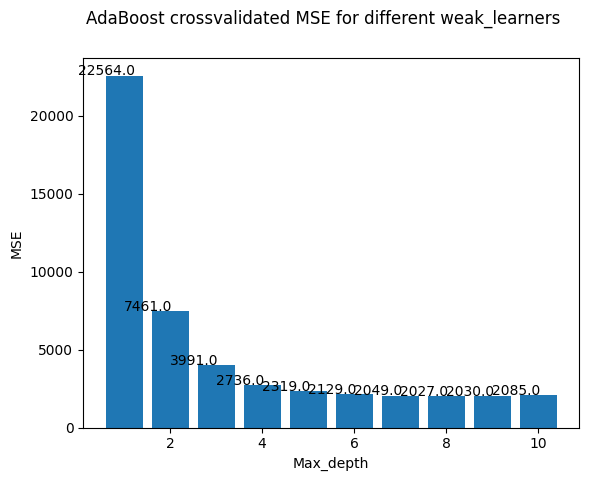

In [132]:
scores = np.array(scores)

fig, ax = plt.subplots(1,1)
bars = ax.bar(depths, scores)
for i in range(len(depths)):
    plt.text(i, scores[i]+10, np.round(scores[i]))
    
ax.set_xlabel("Max_depth")
ax.set_ylabel("MSE")
fig.suptitle("AdaBoost crossvalidated MSE for different weak_learners")
plt.show()

We want to find the AdaBoost model that minimizes the Mean Square Error (among other criteria). It seems to be very little difference among the AdaBoostRegressors after $\operatorname{max depth} \geq 6$. We are thus going to use 6, as we prefer time-efficient short trees over expensive tall trees. 

In [133]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

params= {'n_estimators': [100, 200, 300, 400],
         'learning_rate': [0.01,0.1,0.5,1,2,5,7,10],
         'loss': ['linear', 'square', 'exponential'],
         'random_state': [42]}

adaboost = GridSearchCV(AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=6)), 
                        params, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
adaboost_opt = adaboost.fit(X_train, y_train)

print("best adaboost")
print("------")
print(f"best negative MSE score:  {adaboost.best_score_}")
print(f"best n_estimators value:  {adaboost.best_params_["n_estimators"]}")
print(f"best learning_rate value: {adaboost.best_params_["learning_rate"]}")
print(f"best loss function:       {adaboost.best_params_["loss"]}")

SyntaxError: f-string: unmatched '[' (2725120071.py, line 17)

In [150]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

adaboost_opt = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=6),
                                 n_estimators=400, learning_rate=1, loss='square',random_state=42)
adaboost_opt.fit(X_train, y_train) #we reconstruct the model

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=6), learning_rate=1,
                  loss='square', n_estimators=400, random_state=42)

In [152]:
## Apply the parameters in the code of Bao to find optimals parametrization

# X_reduced = X.drop(columns=['LBMI','LWeight'])
# X_reduced_train,X_reduced_test,y_train,y_test = train_test_split(X_noLBMI,y,test_size=0.2,random_state=42)
# scaler = StandardScaler()
# scaler.fit(X_reduced_train)
# X_reduced_train = scaler.transform(X_reduced_train)
# X_reduced_test = scaler.transform(X_reduced_test)
# adaboost_opt = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5),
#                                  n_estimators=300, learning_rate=1,random_state=42)
# adaboost_opt.fit(X_reduced_train, y_train) #we reconstruct the model
# y_pred_adaboost = adaboost_opt.predict(X_reduced_test)
# mse = mean_squared_error(y_test, y_pred_adaboost)
# r2 = r2_score(y_test, y_pred_adaboost)
# print(mse,r2)

# The Vetle's parametrization performs better.

AdaBoost with stumps      (max_depth=6)


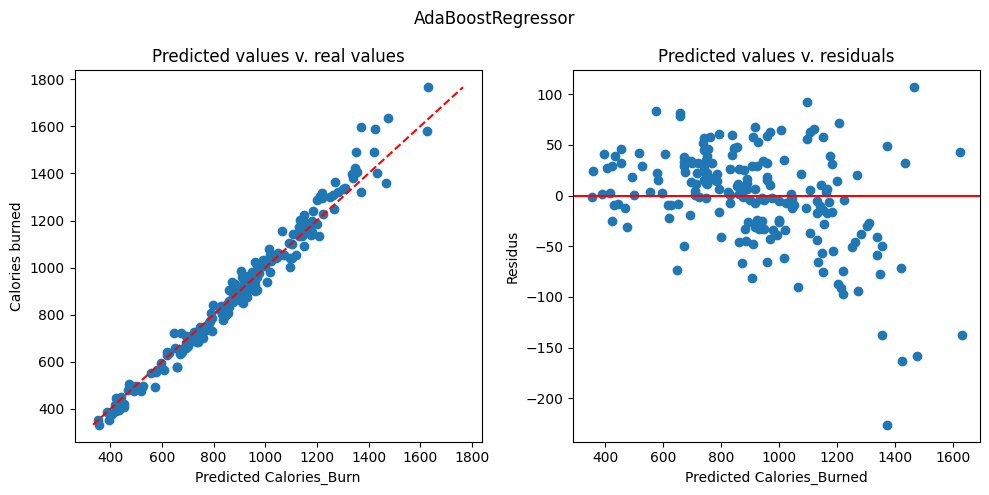

In [153]:
fig1, Axs1 = plot_quant("AdaBoostRegressor",adaboost_opt, X_test, y_test)
print("AdaBoost with stumps      (max_depth=6)")
plt.show()

**Comment:** The AdaBoost model with stumps as weak-learners doesn't seem to work that well. The datapoints in the left-hand side plot are quite dispersed around the diagonal, and the residuals do not seem to be gaussian. 

Let us have a look at the metrics.

In [144]:
pd.set_option('display.width',1000)
quantmodels_log.loc["AdaBoost"] = evaluate_tree_model(adaboost_opt, X_test, y_test)
print(quantmodels_log.round(4))

                      MSE    MAPE        RSE      R2     adjR2          AIC          BIC
Lin reg         1685.9130  0.0371  43.846692  0.9793  0.976563  1494.862199  1570.141189
Lasso           1635.9135  0.0356  42.097977  0.9797  0.978119  1470.991551  1516.813545
Ridge           1669.1280  0.0370  43.627876  0.9794   0.97668  1492.911036  1568.190026
Linear SVR      1731.1750  0.0366        N/A  0.9786       N/A          N/A          N/A
Polynomial SVR  1651.1468  0.0370        N/A  0.9793       N/A          N/A          N/A
Radial SVR       782.2434  0.0248        N/A  0.9903       N/A          N/A          N/A
Dec tree        4895.7232  0.0604  73.859559  0.9345  0.927363   1694.74287  1756.929862
AdaBoost        2289.6979  0.0393  50.949764  0.9678  0.963626  1552.554157  1624.560148


**Remark:** In terms of our metrics, AdaBoost does not perform too well.

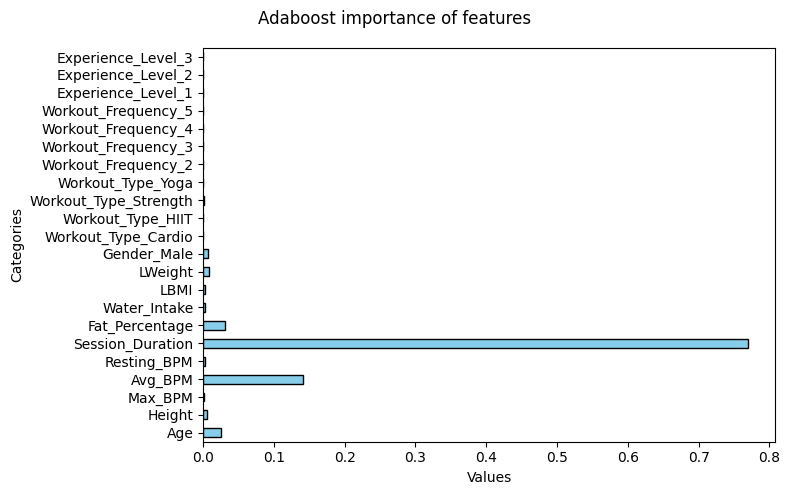

In [107]:
fig, ax = coeff_display(adaboost_opt.feature_importances_, X, title="Adaboost importance of features")
plt.show()

**Comment:** Contrary to other models, AdaBoost doesn't use the 'Gender_Male' parameter. This might be why it is less accurate.

## GradientBoosting Regression

In [339]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

params= {'n_estimators': [200, 300, 400],
         'learning_rate': [1,2,3],
         'loss': ['absolute_error'], #trying and failing gave this
         'max_depth': [1, 2, 3, 4, 5],
         'subsample': [0.5, 0.8, 1.0],
         'random_state': [42]}

grad_boost = GridSearchCV(GradientBoostingRegressor(), params, cv=10, n_jobs=-1)
grad_boost_opt = grad_boost.fit(X_train, y_train)


print("gradientboost")
print("------")
print(f"best R2 score:            {grad_boost.best_score_}")
print(f"best n_estimators value:  {grad_boost.best_params_["n_estimators"]}")
print(f"best learning_rate value: {grad_boost.best_params_["learning_rate"]}")
print(f"best loss function:       {grad_boost.best_params_["loss"]}")
print(f"best max_depth value:     {grad_boost.best_params_["max_depth"]}")
print(f"best subsample value:     {grad_boost.best_params_["subsample"]}")

C:\Users\vetle\anaconda3\envs\stats\Lib\site-packages\sklearn\model_selection\_search.py:1119: RuntimeWarning: overflow encountered in square
  (array - array_means[:, np.newaxis]) ** 2, axis=1, weights=weights


gradientboost
------
best R2 score:            0.9744054919198832
best n_estimators value:  200
best learning_rate value: 1
best loss function:       absolute_error
best max_depth value:     1
best subsample value:     1.0


In [141]:
from sklearn.ensemble import GradientBoostingRegressor

grad_boost_opt = GradientBoostingRegressor(n_estimators=200,
                                           learning_rate=1,
                                           loss='absolute_error',
                                           max_depth=1,
                                           subsample=1.0,
                                           random_state=42).fit(X_train, y_train) #we reconstruct

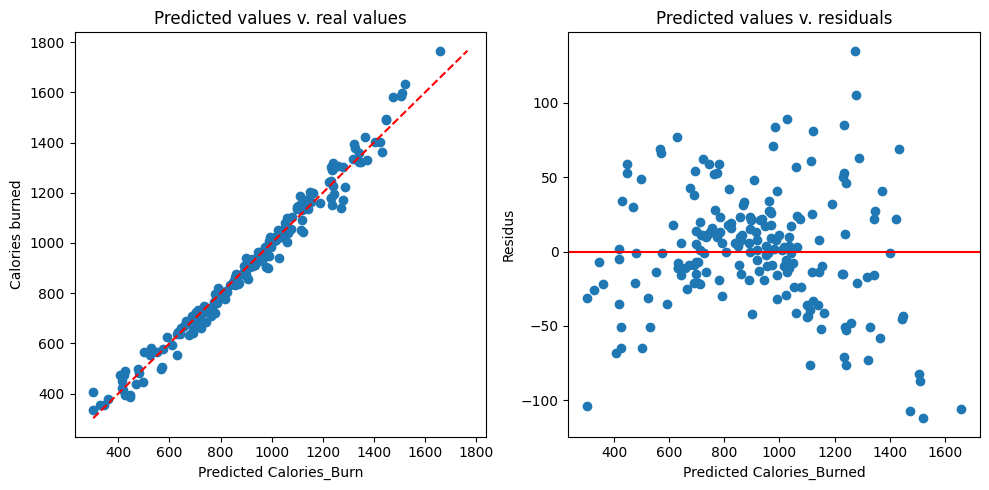

In [357]:
fig, Axs = plot_quant(grad_boost_opt, X_test, y_test)
plt.show()

In [157]:
## Apply the parameters in the code of Bao to find optimals parametrization
from sklearn.ensemble import GradientBoostingRegressor
# X_reduced = X.drop(columns=['LBMI','LWeight'])
X_reduced = X

X_reduced_train,X_reduced_test,y_train,y_test = train_test_split(X_reduced,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
scaler.fit(X_reduced_train)
X_reduced_train = scaler.transform(X_reduced_train)
X_reduced_test = scaler.transform(X_reduced_test)
gbr_model = GradientBoostingRegressor(random_state=42,
                                     n_estimators = 200,
                                     learning_rate = 0.1,
                                      max_depth = 3,
                                      subsample = 0.8)
gbr_model.fit(X_reduced_train,y_train)
y_pred_gbr = gbr_model.predict(X_reduced_test)

                                      
mse = mean_squared_error(y_test, y_pred_gbr)
r2 = r2_score(y_test, y_pred_gbr)

print(f"Mean Squared Error: {mse:.2f}")
print("R2 Score :",r2)

# The Bao's parametrization performs better.

Mean Squared Error: 289.67
R2 Score : 0.9965278012229987


**Comments:** Here we add comments.

In [142]:
pd.set_option('display.width',1000)
quantmodels_log.loc["GradientBoost"] = evaluate_tree_model(grad_boost_opt, X_test, y_test)
print(quantmodels_log.round(4))

                      MSE    MAPE        RSE      R2     adjR2          AIC          BIC
Lin reg         1665.4425  0.0370  43.579684  0.9795  0.976795  1492.479998  1567.758988
Lasso           1635.9135  0.0356  42.097977  0.9797  0.978119  1470.991551  1516.813545
Ridge           1669.1280  0.0370  43.627876  0.9794   0.97668  1492.911036  1568.190026
Linear SVR      1731.1750  0.0366        N/A  0.9786       N/A          N/A          N/A
Polynomial SVR  1651.1468  0.0370        N/A  0.9793       N/A          N/A          N/A
Radial SVR       782.2434  0.0248        N/A  0.9903       N/A          N/A          N/A
Dec tree        4895.7232  0.0604  73.859559  0.9345  0.927363   1694.74287  1756.929862
Rand forest     2368.6873  0.0397  51.821138  0.9671  0.962911   1559.16778   1631.17377
AdaBoost        2289.6979  0.0393  50.949764  0.9678  0.963626  1552.554157  1624.560148
GradientBoost   1612.7231  0.0363  41.915118  0.9797  0.977961  1470.207479  1519.302473


**Comments:** Here we add even more comments.

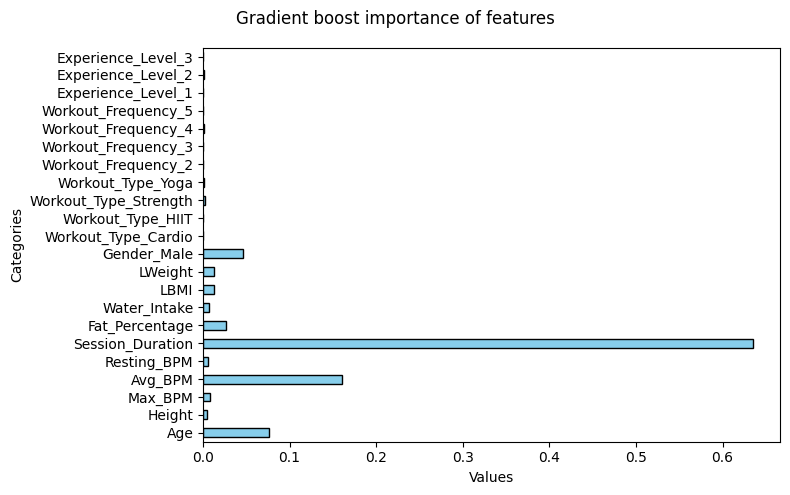

In [144]:
fig, ax = coeff_display(grad_boost_opt.feature_importances_, X, title="Gradient boost importance of features")
plt.show()

## Neural Network

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense,Dropout,BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam, Nadam
from tensorflow.keras.callbacks import  EarlyStopping,LearningRateScheduler

In [ ]:
Xr_train,Xr_temp,yr_train,yr_temp = train_test_split(X,y,test_size=0.2,random_state=42)
Xr_val,Xr_test,yr_val,yr_test = train_test_split(Xr_temp,yr_temp,test_size=0.5,random_state=42)

In [ ]:
def lr_schedule(epoch, lr):
    if epoch < 5:
        return lr  # Keep the learning rate constant for the first 10 epochs
    else:
        return lr * 0.9  # Decay by 10% after 10 epochs

lr_scheduler = LearningRateScheduler(lr_schedule)

keras_model = Sequential()
keras_model.add(Input(shape=(X_train.shape[1],)))
# keras_model.add(Dropout(0.3))
keras_model.add(Dense(64,activation="relu",kernel_initializer='he_normal'))
keras_model.add(BatchNormalization())  
# keras_model.add(Dropout(0.3))
keras_model.add(Dense(32,activation="relu",kernel_initializer='he_normal'))
keras_model.add(BatchNormalization())  

keras_model.add(Dense(32,activation="relu",kernel_initializer='he_normal'))
keras_model.add(BatchNormalization())  
# keras_model.add(Dropout(0.3))
# keras_model.add(Dense(5,activation="relu"))

keras_model.add(Dense(1))


keras_model.compile(optimizer=Nadam(learning_rate=0.5),
                   loss="mse",
                   metrics=["mse"])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,         # number of epochs with no improvement
    mode='min',
    verbose=1,
    restore_best_weights=True  # restores weights from best epoch
)

history = keras_model.fit(Xr_train,yr_train,
                         epochs=200,batch_size=32,
                          callbacks=[early_stop,lr_scheduler],
                         validation_data=(Xr_val,yr_val))

In [ ]:
reg_performance_plot("Neural Network DNN",yr_pred_nn,yr_test)

# Experience Level Prediction

## Training and test data splitting

In [233]:
reg_quali = quali.copy()
reg_quali.remove("Experience_Level")
reg_quali

['Gender', 'Workout_Type', 'Workout_Frequency']

In [317]:
from sklearn.model_selection import train_test_split
gymDumReg = pd.get_dummies(gym,columns=reg_quali)

n = gym.shape[0]
indices = np.arange(n)
X = gymDumReg.drop(columns=['Experience_Level'])
y = gymDumReg['Experience_Level']
X_train,X_test,y_train,y_test,idx_train,idx_test = train_test_split(X,y,indices,test_size=0.2,random_state=42)

In [253]:
print(f"shape of gym before dummifying: {gym.shape}")
print(f"shape of gym after dummifying : {gymDumReg.shape}")

shape of gym before dummifying: (973, 15)
shape of gym after dummifying : (973, 22)


We extract the test index in order to compare our results on for example the PCA'ed data.

In [254]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print("Mean of X_train:", np.mean(X_train, axis=0))  # Should be close to 0
print("Variance of X_train:", np.var(X_train, axis=0))  # Should be close to 1

print('---------------------------------------------------------------------------')

print("Mean of X_test:", np.mean(X_test, axis=0))  
print("Variance of X_test:", np.var(X_test, axis=0))  

Mean of X_train: [-1.14161751e-16 -1.13933427e-15  6.37022568e-16  3.03670257e-16
  3.94999657e-16  5.41126698e-16  8.56213130e-17 -2.73988201e-17
 -4.84045823e-16 -7.80866374e-16  2.46589381e-16 -1.59826451e-17
 -2.51155851e-17  1.05028811e-16 -4.56647002e-17 -1.09595281e-16
 -4.33814652e-17 -3.53901427e-17  4.56647002e-17  2.28323501e-17
  7.99132254e-18]
Variance of X_train: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
---------------------------------------------------------------------------
Mean of X_test: [ 0.02149282 -0.09860144  0.00869134  0.08530579  0.01260262  0.00699846
  0.02600559 -0.04525993 -0.10981037  0.12074845  0.06262187  0.06953931
 -0.06953931 -0.07386357 -0.03490885 -0.0678896   0.18441081  0.17233754
 -0.1542879   0.00931974  0.01171943]
Variance of X_test: [1.01743396 0.88966563 0.97736897 0.95314065 0.91732623 1.18344727
 1.15949658 1.01622327 0.97096611 1.05691906 1.03122782 1.00412102
 1.00412102 0.91743545 0.95400541 0.92551621 1.2025

In [255]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print("---------------")
print(f"y_train shape: {y_train.shape}")
print(f"y_test  shape: {y_test.shape}")

X_train shape: (778, 21)
X_test  shape: (195, 21)
---------------
y_train shape: (778,)
y_test  shape: (195,)


As an exercise, we will perform a Kolmongorov-Smirnov test per feature on the X_train and X_test sets to see if they are significantly different or not.

### Testing goodness of fit on train-test split

In [256]:
from scipy.stats import ks_2samp

goodness = pd.DataFrame(index=X.columns, columns=["p-value", "test_stat"])

for i in range(len(quanti)):
    res = ks_2samp(X_train[:,i], X_test[:,i], alternative="two-sided")
    goodness.loc[X.columns[i],"p-value"],goodness.loc[X.columns[i],"test_stat"] = res.pvalue,res.statistic

In [257]:
from scipy.stats import chi2_contingency

for i in range(len(quanti),X.shape[1]):

    train_vals, train_counts = np.unique_counts(X_train[:,i]) 
    test_vals, test_counts   = np.unique_counts(X_test[:,i]) 

    train_counts = train_counts
    test_counts  = test_counts
    
    # Build contingency table
    contingency = pd.DataFrame({
        'Train': train_counts,
        'Test': test_counts
    })
    
    res = chi2_contingency(contingency)
    goodness.loc[X.columns[i],"p-value"],goodness.loc[X.columns[i],"test_stat"] = res.pvalue,res.statistic

In [258]:
goodness["significant"] = ["*" if p<=0.05 else "" for p in goodness["p-value"]]
print(goodness)

                        p-value test_stat significant
Age                    0.536559  0.063265            
Height                 0.205512  0.084128            
Max_BPM                0.928943  0.042318            
Avg_BPM                0.594076  0.060451            
Resting_BPM            0.936648  0.041672            
Session_Duration       0.482204  0.065981            
Calories_Burned        0.666018   0.05701            
Fat_Percentage         0.507017  0.064709            
Water_Intake           0.531189  0.063483            
LBMI                   0.153046   0.08948            
LWeight                0.544531  0.062778            
Gender_Female          0.431023  0.620065            
Gender_Male            0.431023  0.620065            
Workout_Type_Cardio    0.401706  0.703213            
Workout_Type_HIIT      0.732119  0.117175            
Workout_Type_Strength   0.44541  0.582305            
Workout_Type_Yoga      0.030894  4.658833           *
Workout_Frequency_2    0.045

**Remark:** Most of the p-values are non-significant, meaning we cannot reject the null hypothesis, i.e. that for this variable the train and test set are sampled from the same distribution. However, at a significance level set at 5%, we can reject the hypothesis that Workout_Type_Yoga and Workout_Frequency_2 are sampled from the same distribution for their respective train and test set.

An alternative could be to consider alternative random_state's or seeds for our train-test split until none of the p-values are significant. \
We will not do this.

## Baseline comparison

As a baseline comparison, we will try to construct two dummy models (similar to the intercept model used in prediction). Our goal is to create two models:
- DummyDet will predict the most frequent class every time
- DummyRan will predict a class at random based on the frequences observed in the training data

We will use the sklearn.dummy module to do this.

In [259]:
from sklearn.dummy import DummyClassifier
dummy_det_model = DummyClassifier(strategy='most_frequent')
dummy_ran_model = DummyClassifier(strategy='stratified', random_state=42)
dummy_det = dummy_det_model.fit(X_train, y_train)
dummy_ran = dummy_ran_model.fit(X_train, y_train)

In [260]:
y_chap_dummy_det = dummy_det.predict(X_test)
y_chap_dummy_ran = dummy_ran.predict(X_test)

In [261]:
table_dummy_det = pd.crosstab(y_chap_dummy_det, y_test, rownames=["Predicted"])
print("Logistic regression: most-frequent predictor")
print(table_dummy_det)

Logistic regression: most-frequent predictor
Experience_Level   1   2   3
Predicted                   
2                 78  75  42


**Remark 1:** we need to find a way to evaluate the model a part from the contingency table.
We will import more metrics from the sklearn.metrics module and construct a dataframe to log results.
We would like to have: the precision, recall and fscore (harmonic mean between the two) for our different models. We will thus use the sklearn.metrics function: **precision_recall_fscore_support**. We will not make use of the score output of this function, as it is solely for binary classification.\
Because we are working on a multiclass problem, we need to choose an averaging strategy for computing our scores (which all assume a binary classification problem). We will opt for the 'macro' strategy, which computes the scores for each class individually, and then averages the result across the classes. We could optionally opt for the 'weighted' strategy, which computes a weighted average using the frequency of each class, but since there is no "rare" experience_level, we do not find this relevant.

**Remark 2:** Another way to show the precision of our estimates is to plot them side-by-side to the real test values. We will construct a function: **PredPCA** to do this in the 2-dimensional PCA space from earlier.

In [279]:
def PredPCA(y_hat, y, model_name, target="Experience_Level", X_pca=X_pca, pca=pca, cmap=cmap, idx_test=idx_test):
    fig, Axes = plt.subplots(1,2,figsize=(10,5),sharey=True)
    Axes = np.ravel(Axes)
    for i, mod in enumerate(gym[target].unique()):
        idx_true = (y==mod) * idx_test
        idx_pred = (y_hat==mod) * idx_test
        cnt = np.sum(idx_pred)

        Axes[1].scatter(X_pca[idx_true,0], X_pca[idx_true,1], label=str(mod), color=cmap.colors[i])
        if cnt!=0:
            Axes[0].scatter(X_pca[idx_pred,0], X_pca[idx_pred,1], label=str(mod), color=cmap.colors[i])
    fig.suptitle("Individuals, colored by Experience_Level")
    Axes[0].set_xlabel(f"PC 1 ({100*pca.explained_variance_ratio_[0]:.2f}%)")
    Axes[0].set_ylabel(f"PC 2 ({100*pca.explained_variance_ratio_[1]:.2f}%)")
    Axes[0].legend(title="Experience level")
    Axes[0].set_title(f"Predicted classes by {model_name}") 
    Axes[1].set_xlabel(f"PC 1 ({100*pca.explained_variance_ratio_[0]:.2f}%)")
    Axes[1].legend(title="Experience level")
    Axes[1].set_title(f"Actual classes") 
    return fig, Axes

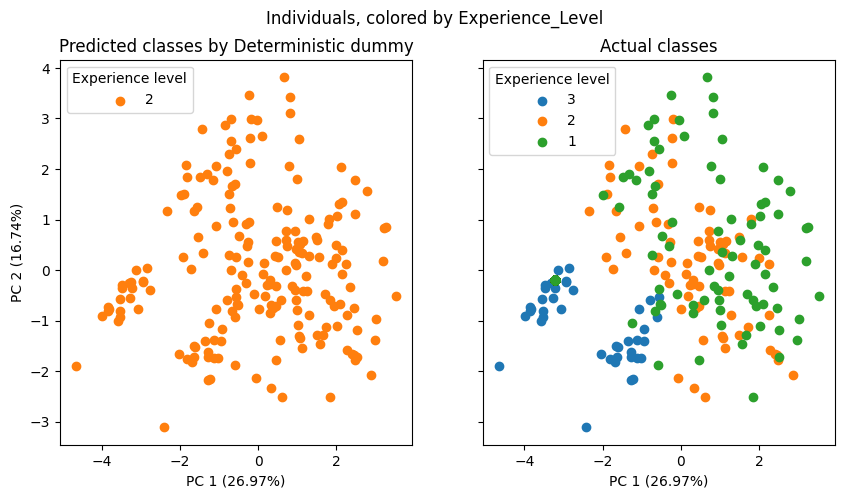

----------
Logistic regression: most-frequent predictor
Experience_Level   1   2   3
Predicted                   
2                 78  75  42
                 Model  Accuracy    Recall  F1_Score
0  Dummy most-frequent  0.333333  0.128205  0.185185


In [287]:
from sklearn.metrics import precision_recall_fscore_support

fig, Axes = PredPCA(y_chap_dummy_det, y_test, "Deterministic dummy")
plt.show()
print("----------")

print("Logistic regression: most-frequent predictor")
print(table_dummy_det)

log_of_logs = pd.DataFrame(columns=["Model", "Accuracy", "Recall", "F1_Score"])
log_of_logs.loc[len(log_of_logs)] = ["Dummy most-frequent", *(precision_recall_fscore_support(y_chap_dummy_det, y_test, average='macro'))[:-1]]
print(log_of_logs)

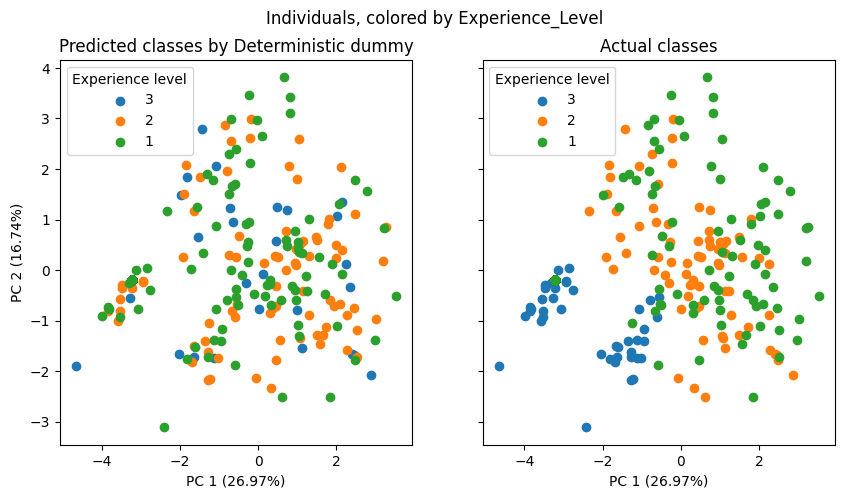

----------
Logistic regression: dummy random sampler
Experience_Level   1   2   3
Predicted                   
1                 40  26  19
2                 33  32  18
3                  5  17   5


                  Model  Accuracy    Recall  F1_Score
0   Dummy most-frequent  0.333333  0.128205  0.185185
1  Dummy random sampler  0.352845  0.347105  0.346929
2  Dummy random sampler  0.352845  0.347105  0.346929
3  Dummy random sampler  0.352845  0.347105  0.346929


In [290]:
table_dummy_ran = pd.crosstab(y_chap_dummy_ran, y_test, rownames=["Predicted"])


fig, Axes = PredPCA(y_chap_dummy_ran, y_test, "Deterministic dummy")
plt.show()
print("----------")

print("Logistic regression: dummy random sampler")
print(table_dummy_ran)
print("\n")



log_of_logs.loc[len(log_of_logs)] = ["Dummy random sampler", *(precision_recall_fscore_support(y_chap_dummy_ran, y_test, average='macro'))[:-1]]
print(log_of_logs)

**Remark:** Taking into account the recall and F1-score parameter, we find that the random (but with set seed) sampler works a lot better than the most-frequent predictor. We will thus use this model as a baseline comparator from now on.

## No penalty logistic regression

### Logistic regression without interactions

In [283]:
from sklearn.linear_model import LogisticRegression

base_log_model = LogisticRegression(penalty=None, solver="lbfgs")
base_log = base_log_model.fit(X_train, y_train)

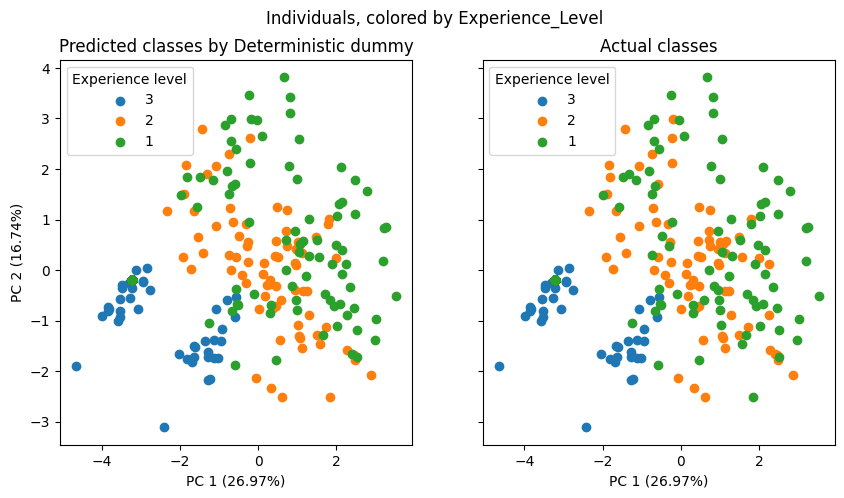

----------
Logistic regression: no penalty logistic regression
Experience_Level   1   2   3
Predicted                   
1                 68  11   0
2                 10  64   0
3                  0   0  42


                  Model  Accuracy    Recall  F1_Score
0   Dummy most-frequent  0.333333  0.128205  0.185185
1  Dummy random sampler  0.352845  0.347105  0.346929
2  Dummy random sampler  0.352845  0.347105  0.346929
3  Dummy random sampler  0.352845  0.347105  0.346929
4  No penalty log. reg.  0.908376  0.908541  0.908434


In [291]:
y_chap_base_log = base_log.predict(X_test)


fig, Axes = PredPCA(y_chap_base_log, y_test, "Deterministic dummy")
plt.show()
print("----------")

table_base_log = pd.crosstab(y_chap_base_log, y_test, rownames=["Predicted"])
print("Logistic regression: no penalty logistic regression")
print(table_base_log)
print("\n")

log_of_logs.loc[len(log_of_logs)] = ["No penalty log. reg.", *(precision_recall_fscore_support(y_chap_base_log, y_test, average='macro'))[:-1]]
print(log_of_logs)

We observe that there is a huge leap in performance from the dummy models to the more sophisticated logistic regression model.
This is to be expected. The model accomplishes to perfectly classify the third experience level.

Let us have a look at the coefficients of the no-penalty logistic regression model:

In [171]:
print(f"shape of coef. matrix: {base_log.coef_.shape}")
# we convert to dataframe
df = pd.DataFrame(data=base_log.coef_, columns=X.columns)
df.insert(0, "INTERCEPT", base_log.intercept_)
print(df)

shape of coef. matrix: (3, 21)
   INTERCEPT       Age    Height   Max_BPM   Avg_BPM  Resting_BPM  \
0   4.991084 -0.062560  2.143389 -0.293721  1.352740    -0.083880   
1  11.853250 -0.223603 -1.815183 -0.313772  1.452281     0.037671   
2 -16.844335  0.286163 -0.328206  0.607493 -2.805021     0.046209   

   Session_Duration  Calories_Burned  Fat_Percentage  Water_Intake  ...  \
0         -5.548669        -2.604305        8.867427     -1.914111  ...   
1         -3.503287        -2.954679        8.991964     -2.209707  ...   
2          9.051956         5.558984      -17.859391      4.123818  ...   

   Gender_Female  Gender_Male  Workout_Type_Cardio  Workout_Type_HIIT  \
0      -2.528742     2.528742             0.264676          -0.142309   
1      -2.806701     2.806701             0.263259          -0.191659   
2       5.335443    -5.335443            -0.527935           0.333968   

   Workout_Type_Strength  Workout_Type_Yoga  Workout_Frequency_2  \
0               0.032050      

**Remark:** It seems like the no-penalty logistic regression uses the Fat_Percentage parameter to distinguish between experience levels 1,2 and experience level 3. It uses Workout_Frequency_2 and Workout_Frequency_4 to distinguish between the different levels.

### Logistic regression with interactions

In order to avoid overfitting, it might be preferred to not add interactions when constructing logistic regression models outside of an academic context. Wanting to test this hypothesis (adding interactions increases overfitting), we chose to create a model with interactions in this project. It also serves as a good Python exercise, as it is quite different to the way you do it in R.

Recalling our correlation matrix from our exploratory analysis, we also see that there is some interest in studying a more complete model.

<Axes: >

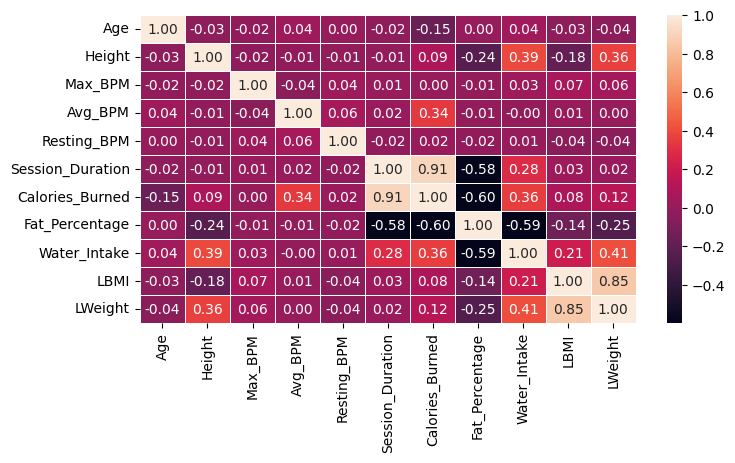

In [174]:
plt.figure(figsize = (8,4))
sns.heatmap(corr, annot = True, fmt='.2f',linewidths=0.5)

In order to construct a model with interactions, we must first expand our feature space to include interaction terms (we will only consider first order interactions). This can be done quite easily using the sklearn.preprocessing package's PolynomialFeatures function.

In [293]:
from sklearn.preprocessing import PolynomialFeatures 

X_train_quant = X_train[:,:11]
X_test_quant  = X_test[:,:11]

X_train_qual  = X_train[:,11:]
X_test_qual   = X_test[:,11:]

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_interact = poly.fit_transform(X_train_quant)
X_test_interact  = poly.transform(X_test_quant)

X_train_interact = np.hstack([X_train_interact, X_train_qual])
X_test_interact  = np.hstack([X_test_interact, X_test_qual])

In [294]:
print(f"We have now passed from {X_train.shape[1]:d} to {X_train_interact.shape[1]:d} variables!")

We have now passed from 21 to 76 variables!


Because the number of variables increased drastically, we will opt for the 'saga' solver which performs better on larger feature spaces. We will also increase the max number of iterations that we allow to 5000.

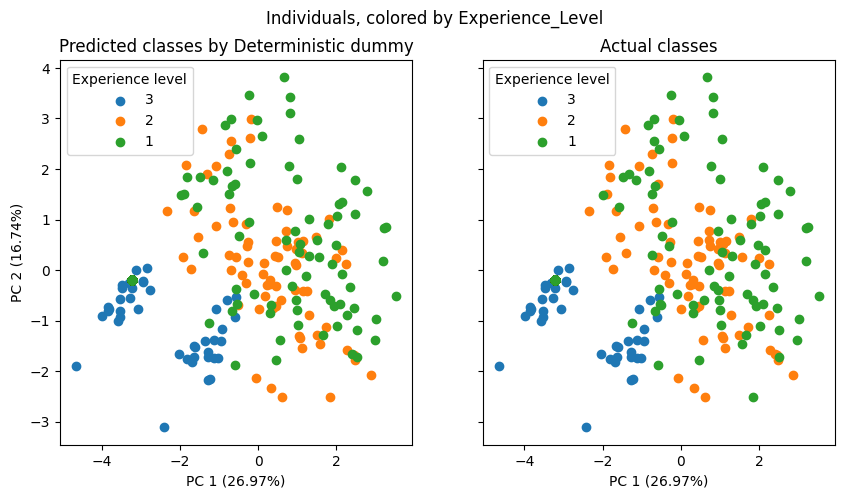

----------
Logistic regression: no penalty logistic regression - with interactions
Experience_Level   1   2   3
Predicted                   
1                 68  11   0
2                 10  64   0
3                  0   0  42


                   Model  Accuracy    Recall  F1_Score
0    Dummy most-frequent  0.333333  0.128205  0.185185
1   Dummy random sampler  0.352845  0.347105  0.346929
2   Dummy random sampler  0.352845  0.347105  0.346929
3   Dummy random sampler  0.352845  0.347105  0.346929
4   No penalty log. reg.  0.908376  0.908541  0.908434
5  Interactive log. reg.  0.908376  0.908541  0.908434
6  Interactive log. reg.  0.908376  0.908541  0.908434


In [296]:
interact_log_model = LogisticRegression(penalty=None, solver="saga", max_iter=5000)
interact_log = interact_log_model.fit(X_train_interact, y_train)

y_chap_interact_log = interact_log.predict(X_test_interact)

fig, Axes = PredPCA(y_chap_interact_log, y_test, "Deterministic dummy")
plt.show()
print("----------")

table_interact_log = pd.crosstab(y_chap_interact_log, y_test, rownames=["Predicted"])

print("Logistic regression: no penalty logistic regression - with interactions")
print(table_interact_log)
print("\n")

log_of_logs.loc[len(log_of_logs)] = ["Interactive log. reg.", *(precision_recall_fscore_support(y_chap_interact_log, y_test, average='macro'))[:-1]]
print(log_of_logs)

**Remark:** the interactive model got the exact same result as the basic logistic regression! This completely eliminates the need for interactions, and we will not consider them for the rest of this exercise.

## Penalized logistic regression

Now that we are introducing penalty terms, we are also introducing the need for parameter optimisation. We will use the GridSearchCV package for this purpose.

### l2 penalty

In [297]:
from sklearn.model_selection import GridSearchCV

param = {"C": [0.01,0.05,0.1,0.15,0.25,0.45,0.75,1,2,5,10,15],
         "solver":["lbfgs"],
         "penalty":["l2"]}

log_ridge_model = GridSearchCV(LogisticRegression(),param,cv=10,n_jobs=-1)
log_ridge       = log_ridge_model.fit(X_train,y_train)
y_chap_log_ridge = log_ridge.predict(X_test)

# Optimal parameters
print(f"Best C for ridge logit: {log_ridge_model.best_params_["C"]}")

Best C for ridge logit: 0.01


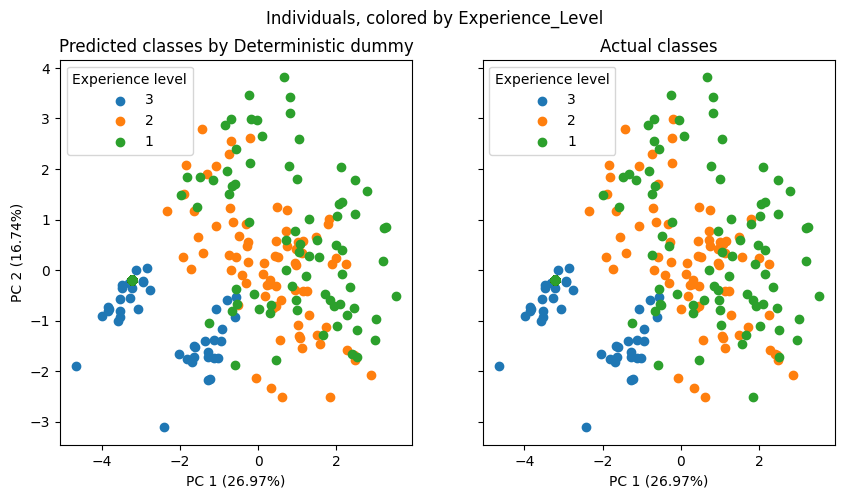

----------
Logistic regression: l2 (Ridge) penalty
Experience_Level   1   2   3
Predicted                   
1                 65  10   0
2                 13  65   0
3                  0   0  42


                   Model  Accuracy    Recall  F1_Score
0    Dummy most-frequent  0.333333  0.128205  0.185185
1   Dummy random sampler  0.352845  0.347105  0.346929
2   Dummy random sampler  0.352845  0.347105  0.346929
3   Dummy random sampler  0.352845  0.347105  0.346929
4   No penalty log. reg.  0.908376  0.908541  0.908434
5  Interactive log. reg.  0.908376  0.908541  0.908434
6  Interactive log. reg.  0.908376  0.908541  0.908434
7   Log. reg. l2 penalty  0.900000  0.900000  0.899782


In [298]:
table_log_ridge = pd.crosstab(y_chap_log_ridge, y_test, rownames=["Predicted"])


fig, Axes = PredPCA(y_chap_log_ridge, y_test, "Deterministic dummy")
plt.show()
print("----------")

print("Logistic regression: l2 (Ridge) penalty")
print(table_log_ridge)
print("\n")

log_of_logs.loc[len(log_of_logs)] = ["Log. reg. l2 penalty", *(precision_recall_fscore_support(y_chap_log_ridge, y_test, average='macro'))[:-1]]
print(log_of_logs)

**Remark:** The l2 (Ridge) penalty doesn't seem to add any significant value to the standard logistic regression. The metrics are still performing impressively well.

### l1 penalty

We will now try the effect of the l1 penalty. We reuse the same values that we picked at random for the penalty parameter.\
Changing to a l1 penalised multimodal problem, we need to opt for the 'saga' solver again. To be sure of convergency, we also increase the max number of iterations as we did previously.

In [299]:
from sklearn.model_selection import GridSearchCV

param = {"C": [0.01,0.05,0.1,0.15,0.25,0.45,0.75,1,2,5,10,15],
         "solver":["saga"],
         "penalty":["l1"],
         "max_iter":[5000]}

log_lasso_model = GridSearchCV(LogisticRegression(),param,cv=10,n_jobs=-1)
log_lasso       = log_lasso_model.fit(X_train,y_train)
y_chap_log_lasso = log_lasso.predict(X_test)

# Optimal parameters
print(f"Best C for lasso logit: {log_lasso_model.best_params_["C"]}")

Best C for lasso logit: 0.45


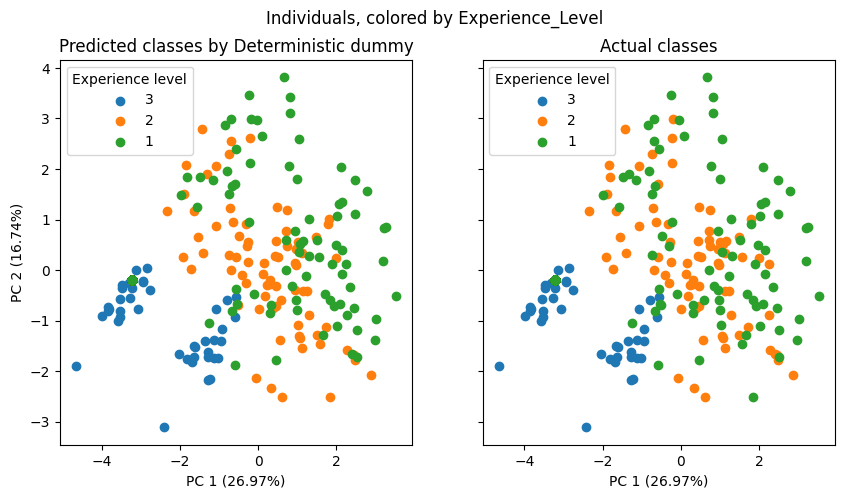

----------
Logistic regression: l1 (Lasso) penalty
Experience_Level   1   2   3
Predicted                   
1                 66  11   0
2                 12  64   0
3                  0   0  42


                    Model  Accuracy    Recall  F1_Score
0     Dummy most-frequent  0.333333  0.128205  0.185185
1    Dummy random sampler  0.352845  0.347105  0.346929
2    Dummy random sampler  0.352845  0.347105  0.346929
3    Dummy random sampler  0.352845  0.347105  0.346929
4    No penalty log. reg.  0.908376  0.908541  0.908434
5   Interactive log. reg.  0.908376  0.908541  0.908434
6   Interactive log. reg.  0.908376  0.908541  0.908434
7    Log. reg. l2 penalty  0.900000  0.900000  0.899782
8    Log. reg. l1 penalty  0.899829  0.899749  0.899765
9    Log. reg. l1 penalty  0.899829  0.899749  0.899765
10   Log. reg. l1 penalty  0.899829  0.899749  0.899765


In [302]:
table_log_lasso = pd.crosstab(y_chap_log_lasso, y_test, rownames=["Predicted"])


fig, Axes = PredPCA(y_chap_log_lasso, y_test, "Deterministic dummy")
plt.show()
print("----------")

print("Logistic regression: l1 (Lasso) penalty")
print(table_log_lasso)
print("\n")

log_of_logs.loc[len(log_of_logs)] = ["Log. reg. l1 penalty", *(precision_recall_fscore_support(y_chap_log_lasso, y_test, average='macro'))[:-1]]
print(log_of_logs)

**Remark:** We observe that the optimal weight for the l1 penalty term was 0.45, which means that GridSearchCV found it to have a more significant role than the l2 penalty term, which got a weight of 0.01 (the minimum value of our selection). However, looking at the different metrics we see almost no change whatsoever in neither the accuracy nor the recall (and thus no change in the f1-score). Additionally, the penalisation term increases the time-complexity of our computation.

This means that the penalisation of the logistic regression has **no interest**. We do not deem it relevant to study the elastic net penalty, as it is a mix of the l1 and l2 penalties and both of these have performed worse than expected. 

## Logistic Regression ++

Having observed that the best logistic regression model was the standard/base logistic regression with no penalty and without interactions, we will try to push this model further. Let's go!

As observed before, our logistic regression model kept all the parameters from our dataset. Our first attempt at increasing the robustness of our logistic regression model will be to test whether we can omit certain of these parameters.

In [308]:
from sklearn.feature_selection import RFECV

rfecv_log_model = RFECV(estimator=base_log_model, cv=10, scoring="f1_macro", n_jobs=-1)
rfecv_log       = rfecv_log_model.fit(X_train, y_train)

We should keep the following features:
Index(['Session_Duration', 'Fat_Percentage', 'Gender_Female', 'Gender_Male',
       'Workout_Frequency_2', 'Workout_Frequency_3', 'Workout_Frequency_4',
       'Workout_Frequency_5'],
      dtype='object')




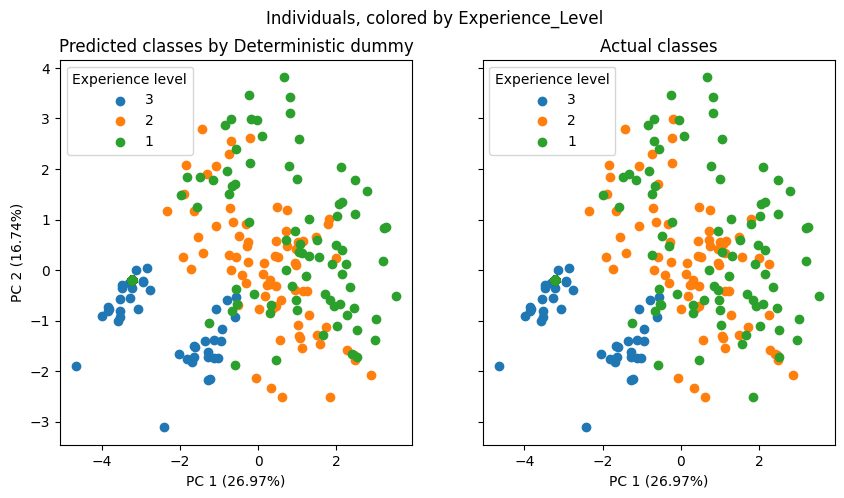

----------
RFECV optimised logistic regression: no penalty
Experience_Level   1   2   3
Predicted                   
1                 66  11   0
2                 12  64   0
3                  0   0  42


                    Model  Accuracy    Recall  F1_Score
0     Dummy most-frequent  0.333333  0.128205  0.185185
1    Dummy random sampler  0.352845  0.347105  0.346929
2    Dummy random sampler  0.352845  0.347105  0.346929
3    Dummy random sampler  0.352845  0.347105  0.346929
4    No penalty log. reg.  0.908376  0.908541  0.908434
5   Interactive log. reg.  0.908376  0.908541  0.908434
6   Interactive log. reg.  0.908376  0.908541  0.908434
7    Log. reg. l2 penalty  0.900000  0.900000  0.899782
8    Log. reg. l1 penalty  0.899829  0.899749  0.899765
9    Log. reg. l1 penalty  0.899829  0.899749  0.899765
10   Log. reg. l1 penalty  0.899829  0.899749  0.899765
11       RFECV no penalty  0.899829  0.899749  0.899765
12       RFECV no penalty  0.899829  0.899749  0.899765
13       R

In [307]:
print("We should keep the following features:")

print(X.columns[rfecv_log.support_])
print("\n")

y_chap_rfecv_log = rfecv_log.estimator_.predict(X_test[:,rfecv_log.support_])
table_rfecv_log  = pd.crosstab(y_chap_rfecv_log, y_test, rownames=["Predicted"])

fig, Axes = PredPCA(y_chap_rfecv_log, y_test, "Deterministic dummy")
plt.show()
print("----------")

print("RFECV optimised logistic regression: no penalty")

print(table_rfecv_log)
print("\n")

log_of_logs.loc[len(log_of_logs)] = ["RFECV no penalty", *(precision_recall_fscore_support(y_chap_rfecv_log, y_test, average='macro'))[:-1]]
print(log_of_logs)

**Remark:** It thus seems like we can obtain an adequately good estimation of *Experience_Level* using solely the session duration, fat percentage, gender, and workout frequency variables. (We chose to use 'f1_macro' as a scoring parameter as it combines both accuracy and recall).\
However, since robustness is not a criteria on which we are scoring our functions, it is basically indifferent whether we keep the base logistic regression model or the RFECV optimised one. Let us pass unto some more advanced models.

## Decision tree

Among the more advanced classification techniques, we will start with a simple one: the decision tree.

### Optimisation

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param = {"criterion": ["gini", "entropy", "log_loss"],
         "splitter": ["best", "random"],
         "max_depth": [None, 5, 6, 7, 8],
         "min_samples_split": [2, 3, 4, 5],
         "min_samples_leaf": [2, 3, 4, 5],
         "max_features": [None, "sqrt", "log2"],
         'max_leaf_nodes': [None, 10, 20, 50],
         "random_state": [2]
        }
decision_tree_model = GridSearchCV(DecisionTreeClassifier(),param,cv=10,n_jobs=-1)
decision_tree       = decision_tree_model.fit(X_train,y_train)

NameError: name 'X_train' is not defined

In [377]:
# Optimal parameters
print("Best tree:")
print("-----------------")
print(f" - criterion=         {decision_tree_model.best_params_["criterion"]}")
print(f" - splitter=          {decision_tree_model.best_params_["splitter"]}")
print(f" - max_depth=         {decision_tree_model.best_params_["max_depth"]}")
print(f" - min_samples_split= {decision_tree_model.best_params_["min_samples_split"]}")
print(f" - min_samples_leaf=  {decision_tree_model.best_params_["min_samples_leaf"]}")
print(f" - max_features=      {decision_tree_model.best_params_["max_features"]}")
print(f" - max_leaf_nodes=    {decision_tree_model.best_params_["max_leaf_nodes"]}")

# we save the optimal parametrs

criterion_opt = decision_tree_model.best_params_["criterion"]
splitter_opt = decision_tree_model.best_params_["splitter"]
max_depth_opt = decision_tree_model.best_params_["max_depth"]
min_samples_split_opt = decision_tree_model.best_params_["min_samples_split"]
min_samples_leaf_opt = decision_tree_model.best_params_["min_samples_leaf"]
max_features_opt = decision_tree_model.best_params_["max_features"]
max_leaf_nodes_opt = decision_tree_model.best_params_["max_leaf_nodes"]

Best tree:
-----------------
 - criterion=         entropy
 - splitter=          best
 - max_depth=         6
 - min_samples_split= 2
 - min_samples_leaf=  5
 - max_features=      None
 - max_leaf_nodes=    None


### Visualisation with Sklearn.tree

In [1]:
decision_tree = DecisionTreeClassifier(criterion=criterion_opt,
                                       splitter=splitter_opt,
                                       max_depth=max_depth_opt,
                                       min_samples_split=min_samples_split_opt,
                                       min_samples_leaf=min_samples_leaf_opt,
                                       max_features=max_features_opt,
                                       max_leaf_nodes=max_leaf_nodes_opt,
                                       random_state=2) # we remake the tree
decision_tree_model = decision_tree.fit(X_train,y_train)
y_chap_decision_tree = decision_tree.predict(X_test)

NameError: name 'DecisionTreeClassifier' is not defined

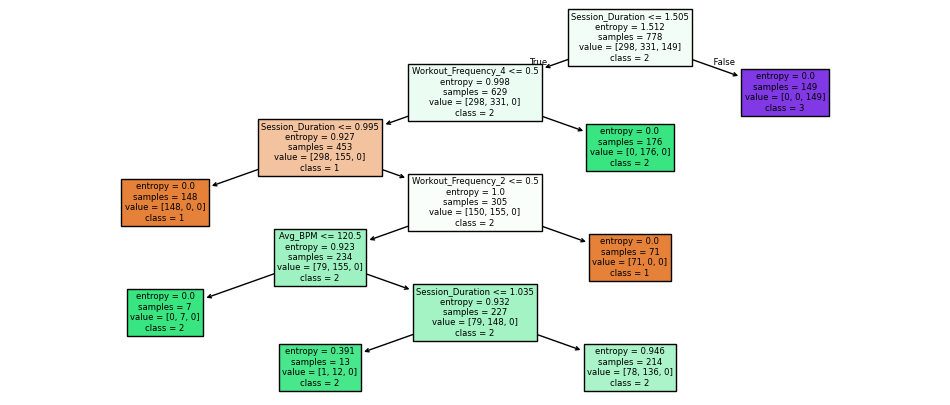

In [403]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(1,1,figsize=(12,5))
plot_tree(decision_tree, feature_names=X_train.columns, class_names=['1','2','3'], filled=True, ax=ax)
plt.show()

### Interpretation

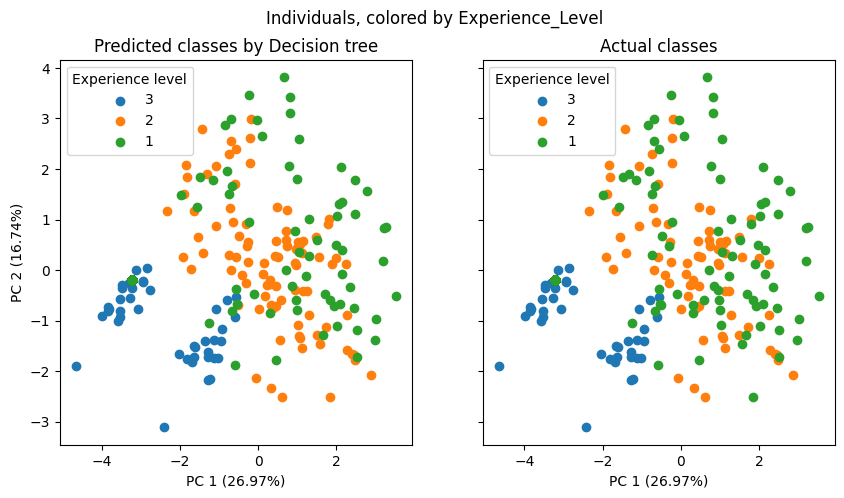

----------
Optimised decision tree
Experience_Level   1   2   3
Predicted                   
1                 63   0   0
2                 15  75   0
3                  0   0  42


                    Model  Accuracy    Recall  F1_Score
0     Dummy most-frequent  0.333333  0.128205  0.185185
1    Dummy random sampler  0.352845  0.347105  0.346929
2    Dummy random sampler  0.352845  0.347105  0.346929
3    Dummy random sampler  0.352845  0.347105  0.346929
4    No penalty log. reg.  0.908376  0.908541  0.908434
5   Interactive log. reg.  0.908376  0.908541  0.908434
6   Interactive log. reg.  0.908376  0.908541  0.908434
7    Log. reg. l2 penalty  0.900000  0.900000  0.899782
8    Log. reg. l1 penalty  0.899829  0.899749  0.899765
9    Log. reg. l1 penalty  0.899829  0.899749  0.899765
10   Log. reg. l1 penalty  0.899829  0.899749  0.899765
11       RFECV no penalty  0.899829  0.899749  0.899765
12       RFECV no penalty  0.899829  0.899749  0.899765
13       RFECV no penalty  0.89982

In [380]:
table_dectree_log  = pd.crosstab(y_chap_decision_tree, y_test, rownames=["Predicted"])

fig, Axes = PredPCA(y_chap_decision_tree, y_test, "Decision tree")
plt.show()
print("----------")

print("Optimised decision tree")

print(table_dectree_log)
print("\n")
log_of_logs.loc[len(log_of_logs)] = ["Decision tree", *(precision_recall_fscore_support(y_chap_decision_tree, y_test, average='macro'))[:-1]]
print(log_of_logs)

**Comments:** 
- Introducing even a basic decision tree increases our overall accuracy, recall, and f1-score. This is coherent with the tree being a more advanced method than a logistic regression. 
- The increase is however, not spectacular (from .90 to .93). Firstly, we're in an ideal scenario where a simple logistic regression achieves .90 accuracy. Secondly, although more advanced, the decision tree remains one of the simpler classifiers.

## Random forest

### Optimisation

In [449]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


param = {"n_estimators": [10, 50, 100, 200, 500, 600],
         "criterion": [criterion_opt],
         "max_depth": [max_depth_opt],
         "min_samples_split": [min_samples_split_opt],
         "min_samples_leaf": [min_samples_leaf_opt],
         "max_features": [max_features_opt],
         'max_leaf_nodes': [max_leaf_nodes_opt],
         "bootstrap": [True, False],
         "random_state": [2]
        } #same as for decision tree

random_forest_model = GridSearchCV(RandomForestClassifier(),param,cv=10,n_jobs=-1)
random_forest       = random_forest_model.fit(X_train,y_train)
print(f"best number of estimators: {random_forest_model.best_params_["n_estimators"]}")
print("Semi-optimised Random Forest")
print("-----------")
n_estimators_opt = random_forest_model.best_params_["n_estimators"]
bootstrap_opt = random_forest_model.best_params_["bootstrap"]

best number of estimators: 10
Semi-optimised Random Forest
-----------


In [ ]:
#full optimisation
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param = {"n_estimators": [10, 50, 100, 200, 500, 700, 1000],
         "criterion": ["gini", "entropy", "log_loss"],
         "max_depth": [None, 5, 6, 7, 8],
         "min_samples_split": [2, 3, 4, 5],
         "min_samples_leaf": [2, 3, 4, 5],
         "max_features": [None, "sqrt", "log2"],
         'max_leaf_nodes': [None, 10, 20, 50],
         "bootstrap": [True, False]
         "random_state": [2]
        }
random_forest_model_FULLOPT = GridSearchCV(RandomForestClassifier(),param,cv=10,n_jobs=-1)

### Interpretation

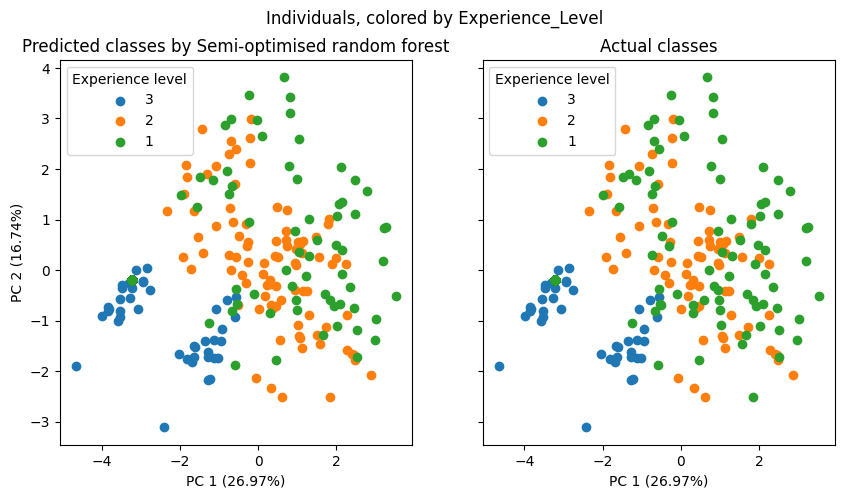

----------
Semi-optimised random forest
Experience_Level   1   2   3
Predicted                   
1                 63   0   0
2                 15  75   0
3                  0   0  42


                           Model  Accuracy    Recall  F1_Score
0            Dummy most-frequent  0.333333  0.128205  0.185185
1           Dummy random sampler  0.352845  0.347105  0.346929
2           Dummy random sampler  0.352845  0.347105  0.346929
3           Dummy random sampler  0.352845  0.347105  0.346929
4           No penalty log. reg.  0.908376  0.908541  0.908434
5          Interactive log. reg.  0.908376  0.908541  0.908434
6          Interactive log. reg.  0.908376  0.908541  0.908434
7           Log. reg. l2 penalty  0.900000  0.900000  0.899782
8           Log. reg. l1 penalty  0.899829  0.899749  0.899765
9           Log. reg. l1 penalty  0.899829  0.899749  0.899765
10          Log. reg. l1 penalty  0.899829  0.899749  0.899765
11              RFECV no penalty  0.899829  0.899749  0.8

In [450]:
y_chap_random_forest = random_forest.predict(X_test)
table_randfor_log  = pd.crosstab(y_chap_random_forest, y_test, rownames=["Predicted"])

fig, Axes = PredPCA(y_chap_random_forest, y_test, "Semi-optimised random forest")
plt.show()
print("----------")

print("Semi-optimised random forest")

print(table_randfor_log)
print("\n")
log_of_logs.loc[len(log_of_logs)] = ["Semi-optimised random forest", *(precision_recall_fscore_support(y_chap_random_forest, y_test, average='macro'))[:-1]]
print(log_of_logs)